In [1]:
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPolygon
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import numpy as np
import seaborn as sns

# FIGURE 1: US land use by demographics of land owners, Indigenous nations, and overall population demogrpahics
__________
___________

In [47]:
states = gpd.read_file("./USDA_maps/cb_2018_us_state_500k/cb_2018_us_state_500k.shp") # Path to the shapefile
print(states["NAME"]) # print out state names

0                                      Mississippi
1                                   North Carolina
2                                         Oklahoma
3                                         Virginia
4                                    West Virginia
5                                        Louisiana
6                                         Michigan
7                                    Massachusetts
8                                            Idaho
9                                          Florida
10                                        Nebraska
11                                      Washington
12                                      New Mexico
13                                     Puerto Rico
14                                    South Dakota
15                                           Texas
16                                      California
17                                         Alabama
18                                         Georgia
19                             

In [48]:
# remove territories, etc.
remove_states = ["Puerto Rico",
                 "District of Columbia",
                 "American Samoa",
                 "United States Virgin Islands",
                 "Guam",
                 "Commonwealth of the Northern Mariana Islands",
                ]

# create new df of just states
just_states = states[~states["NAME"].isin(remove_states)].reset_index()

just_states

,index,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,0,28,01779790,0400000US28,28,MS,Mississippi,00,121533519481,3926919758,"MULTIPOLYGON (((-88.50297 30.21524, -88.49176 ..."
1,1,37,01027616,0400000US37,37,NC,North Carolina,00,125923656064,13466071395,"MULTIPOLYGON (((-75.72681 35.93584, -75.71827 ..."
2,2,40,01102857,0400000US40,40,OK,Oklahoma,00,177662925723,3374587997,"POLYGON ((-103.00256 36.52659, -103.00219 36.6..."
3,3,51,01779803,0400000US51,51,VA,Virginia,00,102257717110,8528531774,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ..."
4,4,54,01779805,0400000US54,54,WV,West Virginia,00,62266474513,489028543,"POLYGON ((-82.6432 38.16909, -82.643 38.16956,..."
5,5,22,01629543,0400000US22,22,LA,Louisiana,00,111897594374,23753621895,"MULTIPOLYGON (((-88.8677 29.86155, -88.86566 2..."
6,6,26,01779789,0400000US26,26,MI,Michigan,00,146600952990,103885855702,"MULTIPOLYGON (((-83.19159 42.03537, -83.18993 ..."
7,7,25,00606926,0400000US25,25,MA,Massachusetts,00,20205125364,7129925486,"MULTIPOLYGON (((-70.23405 41.28565, -70.22361 ..."
8,8,16,01779783,0400000US16,16,ID,Idaho,00,214049787659,2391722557,"POLYGON ((-117.24267 44.39655, -117.23484 44.3..."
9,9,12,00294478,0400000US12,12,FL,Florida,00,138949136250,31361101223,"MULTIPOLYGON (((-80.17628 25.52505, -80.17395 ..."


In [49]:
# separate single and multipolygon states
single_states = ["Oklahoma",
                 "West Virginia",
                 "Idaho",
                 "Nebraska",
                 "New Mexico",
                 "South Dakota",
                 "Pennsylvania",
                 "Missouri",
                 "Colorado",
                 "Utah",
                 "Tennessee",
                 "Wyoming",
                 "Kansas",
                 "Nevada",
                 "Illinois",
                 "Vermont",
                 "Montana",
                 "Iowa",
                 "Arizona",
                 "New Jersey",
                 "North Dakota",
                 "Arkansas",
                 "Indiana"]

multi_states = [
                "Alaska",
                "Hawaii",
                "Mississippi",
                "North Carolina",
                "Virginia",
                "Louisiana",
                "Michigan",
                "Massachusetts",
                "Florida",
                "Washington",
                "Texas",
                "California",
                "Alabama",
                "Georgia",
                "New York",
                "South Carolina",
                "New Hampshire",
                "Maryland",
                "Maine",
                "Delaware",
                "Rhode Island",
                "Kentucky",
                "Ohio",
                "Wisconsin",
                "Oregon",
                "Minnesota",
                "Connecticut"]

# Retrieve polygons

### Single polygons

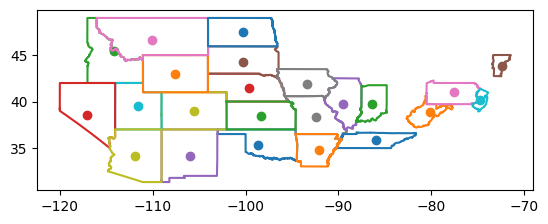

In [50]:
state_names_s = [] # lists to store data from single polygon states
state_coords_s = []
state_centroids_s = []

for s in single_states:

    curr_state=s # select current state
    curr_coords = just_states[just_states["NAME"]==curr_state].get_coordinates() # get coordinates as dataframe
    curr_coord_list = [list(curr_coords["x"]), list(curr_coords["y"])] # convert to list of lists
    
    # get centroid
    cen_x_val = (min(curr_coord_list[0])+max(curr_coord_list[0]))/2
    cen_y_val = (min(curr_coord_list[1])+max(curr_coord_list[1]))/2
    curr_centroid = [cen_x_val, cen_y_val]

    # save data
    state_names_s.append(curr_state)
    state_coords_s.append(curr_coord_list)
    state_centroids_s.append(curr_centroid)
    
    # check plot
    plt.plot(curr_coord_list[0], curr_coord_list[1])
    plt.scatter(curr_centroid[0], curr_centroid[1])
    plt.gca().set_aspect("equal")

### Multipolygons

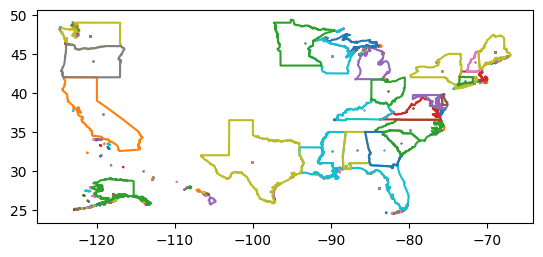

In [51]:
# info for scaling and translating Alaska
ak_scale=0.2
ak_xval = -118
ak_yval = 27

# info for scaling and translating Hawaii
hi_scale=0.7
hi_xval = -113
hi_yval = 29

################

state_names_m = [] # lists to store data from multipolygon states
state_coords_m = []
state_centroids_m = []

for m in multi_states:

    curr_state=m # select current state
    curr_df = just_states[just_states["NAME"]==curr_state] # get coordinates as dataframe
    
    # expand polygons
    polys = (
        gpd.GeoSeries(
            curr_df.dropna()["geometry"].apply(lambda g: g.geoms).explode()
        )
        .reset_index(drop=True)
    )
    
    # get coordinates for each polygon
    curr_coords = []
    for geom in polys:
        curr_coords.append(list(geom.exterior.coords))

    if curr_state=="Alaska": # remove bad islands from Alaska data
        curr_coords = curr_coords[14:]
    
    # unzip coordinates and create list of list of coordinates
    curr_coord_list = []
    for i in range(len(curr_coords)):
        unzipped_coord = list(zip(*curr_coords[i]))
        unzipped_list = [list(unzipped_coord)[0],list(unzipped_coord)[1]]
        curr_coord_list.append(unzipped_list)
    
    # calcualte the centroid of bounding box
    cen_x_vals = []
    cen_y_vals = []
    for i in range(len(curr_coord_list)):
        for j in range(len(curr_coord_list[i][0])):
            cen_x_vals.append(curr_coord_list[i][0][j])
        for k in range(len(curr_coord_list[i][1])):
            cen_y_vals.append(curr_coord_list[i][1][k])
    cen_x_val = (min(cen_x_vals)+max(cen_x_vals))/2
    cen_y_val = (min(cen_y_vals)+max(cen_y_vals))/2
    curr_centroid = [cen_x_val, cen_y_val]

    if curr_state=="Alaska": # translate and scale Alaska
        ak_centroid=curr_centroid # save for later with nations
        ak_coord_list = []
        for i in range(len(curr_coord_list)):
            ak_coord_x = list((np.array(curr_coord_list[i][0])-curr_centroid[0])*ak_scale+ak_xval)
            ak_coord_y = list((np.array(curr_coord_list[i][1])-curr_centroid[1])*ak_scale+ak_yval)
            ak_coord_list.append([ak_coord_x, ak_coord_y])
        curr_coord_list = ak_coord_list
        curr_centroid = [ak_xval, ak_yval]

    if curr_state=="Hawaii": # translate and scale Hawaii
        hi_centroid=curr_centroid # save for later with nations
        hi_coord_list = []
        for i in range(len(curr_coord_list)):
            hi_coord_x = list((np.array(curr_coord_list[i][0])-curr_centroid[0])*hi_scale+hi_xval)
            hi_coord_y = list((np.array(curr_coord_list[i][1])-curr_centroid[1])*hi_scale+hi_yval)
            hi_coord_list.append([hi_coord_x, hi_coord_y])
        curr_coord_list = hi_coord_list
        curr_centroid = [hi_xval, hi_yval]

    # save data
    state_names_m.append(curr_state)
    state_coords_m.append(curr_coord_list)
    state_centroids_m.append(curr_centroid)
        
    # check plot
    for i in range(len(curr_coord_list)):
        plt.plot(curr_coord_list[i][0], curr_coord_list[i][1])
        plt.scatter(curr_centroid[0], curr_centroid[1], s=0.1)
        plt.gca().set_aspect("equal")


# Get grid points

In [52]:
#################################
#################################
#################################
# SET THE STEP VALUE FOR THE GRID
step = 0.17
#################################
#################################
#################################

### Single polygon grid

In [53]:
state_grid_s = []

for i in range(len(state_names_s)):

    print(state_names_s[i])

    curr_coords_x = state_coords_s[i][0]
    curr_coords_y = state_coords_s[i][1]

    # create grid of points
    minx = min(curr_coords_x)
    maxx = max(curr_coords_x)
    miny = min(curr_coords_y)
    maxy = max(curr_coords_y) 
    x_range = np.arange(minx, maxx, step)
    y_range = np.arange(miny, maxy, step)
    grid_x = []
    grid_y = []
    for i in x_range:
        for j in y_range:
            grid_x.append(i)
            grid_y.append(j)
    
    # create shapely polygon
    sh_poly = []
    for i in range(len(curr_coords_x)):
        sh_poly.append( (curr_coords_x[i],curr_coords_y[i]) )
    poly_s = Polygon(sh_poly)
    
    # retrieve points in shapely polygon
    x_points = []
    y_points = []
    for i in range(len(grid_x)):
        pt = Point(grid_x[i], grid_y[i])
        if poly_s.contains(pt):
            x_points.append(grid_x[i])
            y_points.append(grid_y[i])
        else:
            continue

    # save the grid points
    state_grid_s.append([x_points, y_points])


Oklahoma
West Virginia
Idaho
Nebraska
New Mexico
South Dakota
Pennsylvania
Missouri
Colorado
Utah
Tennessee
Wyoming
Kansas
Nevada
Illinois
Vermont
Montana
Iowa
Arizona
New Jersey
North Dakota
Arkansas
Indiana


### Multipolygon grid

In [54]:
state_grid_m = []

for i in range(len(state_names_m)):

    print(state_names_m[i])

    curr_m_state_coords = state_coords_m[i]

    x_polys = [] # save polygons
    y_polys = [] 
    for j in range(len(curr_m_state_coords)): # for each polygon 
        curr_poly = curr_m_state_coords[j]
        x_polys.append(curr_poly[0]) # save the current poly
        y_polys.append(curr_poly[1])
        
    # flatten polygons to find min and max for grid
    flat_x = []
    flat_y = []
    for k in range(len(x_polys)):
        curr_xpoly = x_polys[k]
        curr_ypoly = y_polys[k]
        for l in range(len(curr_xpoly)):
            flat_x.append(curr_xpoly[l])
            flat_y.append(curr_ypoly[l])

    # create grid of points
    minx = min(flat_x)
    maxx = max(flat_x)
    miny = min(flat_y)
    maxy = max(flat_y) 
    x_range = np.arange(minx, maxx, step)
    y_range = np.arange(miny, maxy, step)
    grid_x = []
    grid_y = []
    for m in x_range:
        for n in y_range:
            grid_x.append(m)
            grid_y.append(n)

    # create shapely multipolygon
    multi_list = [] # list of Polygons for MultiPolygon
    for o in range(len(x_polys)):

        curr_xpoly = x_polys[o]
        curr_ypoly = y_polys[o]
        
        sh_poly = []
        for p in range(len(curr_xpoly)):
            sh_poly.append( (curr_xpoly[p],curr_ypoly[p]) )
            
        poly_m = Polygon(sh_poly)
        multi_list.append(poly_m)
        
    multi_poly = MultiPolygon(multi_list)

    # retrieve points in shapely polygon
    x_points = []
    y_points = []
    for q in range(len(grid_x)):
        pt = Point(grid_x[q], grid_y[q])
        if multi_poly.contains(pt):
            x_points.append(grid_x[q])
            y_points.append(grid_y[q])
        else:
            continue

    # save the grid points
    state_grid_m.append([x_points, y_points])

Alaska
Hawaii
Mississippi
North Carolina
Virginia
Louisiana
Michigan
Massachusetts
Florida
Washington
Texas
California
Alabama
Georgia
New York
South Carolina
New Hampshire
Maryland
Maine
Delaware
Rhode Island
Kentucky
Ohio
Wisconsin
Oregon
Minnesota
Connecticut


### Set order of grid points

In [55]:
state_names = state_names_s + state_names_m
state_grid = state_grid_s + state_grid_m

In [56]:
grid_lens = [] # store the length of each grid
grid_ordered = [] # store the ordered coords for each grid

for i in range(len(state_names)):

    curr_state=state_names[i]
    
    curr_grid = state_grid[i]
    curr_grid_x = curr_grid[0]
    curr_grid_y = curr_grid[1]
    
    mean_grid_x = sum(curr_grid_x)/len(curr_grid_x)
    mean_grid_y = sum(curr_grid_y)/len(curr_grid_y)
    
    dists = []
    for j in range(len(curr_grid_x)):
        dists.append(np.sqrt((curr_grid_x[j]-mean_grid_x)**2 + (curr_grid_y[j]-mean_grid_y)**2))
    
    indices = np.argsort(dists)
    grid_lens.append(len(indices))
    
    grid_x = []
    grid_y = []
    for k in indices:
        grid_x.append(curr_grid_x[k])
        grid_y.append(curr_grid_y[k])
    
    grid_ordered.append([grid_x, grid_y])
    
    

# Get colors of grid points

In [57]:
# adjust factor keeps max points for a state in bounds
adjust=-100

In [58]:
# read in data
df = pd.read_csv("./USDA_maps/acres_farms_principal_producer_2017.csv")

# remove US data for now
df = df.iloc[1:,:]

# get the total value for each state
df["total"] = df["white"]+df["Latino"]+df["Indigenous"]+df["Asian"]+df["Black"]+df["PacificIslander"]+df["Mixed"]

# add the number of points per state and value per point
temp_df = pd.DataFrame({"state":state_names, "points":grid_lens})
df = pd.merge(df,temp_df,on="state")
df["val_pt"] = df["total"]/df["points"]

# find the state with the maximum value per point
max_state = df["state"][df["val_pt"]==df["val_pt"].max()].item()
print("The max value per point state is", max_state)

# set the value per point value
# in this case: acres per point
val_pt = np.round(df["val_pt"].max(),-1)-adjust
print(val_pt)

The max value per point state is Kansas
64510.0


In [59]:
#######################
# VAL_PT VALUE OVERRIDE
val_pt = 75000
#######################

In [60]:
state_cols = [] # get colors of points for each state
for i in range(len(state_names)):

    curr_state=state_names[i]
    
    # get colors
    curr_df = df[df["state"]==curr_state]
    nPacific = int(np.round(((curr_df["PacificIslander"])*(1/val_pt)).item()))
    nIndigenous = int(np.round(((curr_df["Indigenous"])*(1/val_pt)).item()))
    nMixed = int(np.round(((curr_df["Mixed"])*(1/val_pt)).item()))
    nAsian = int(np.round(((curr_df["Asian"])*(1/val_pt)).item()))
    nBlack = int(np.round(((curr_df["Black"])*(1/val_pt)).item()))
    nLatino = int(np.round(((curr_df["Latino"])*(1/val_pt)).item()))
    nwhite = int(np.round(((curr_df["white"])*(1/val_pt)).item()))
    
    colors = []
    for i in range(nPacific):
        colors.append("#1b9e77") # teal
    for i in range(nIndigenous):
        colors.append("#d95f02") # orange
    for i in range(nMixed):
        colors.append("#7570b3") # purple
    for i in range(nAsian):
        colors.append("#e7298a") # magenta
    for i in range(nBlack):
        colors.append("k") # black
    for i in range(nLatino):
        colors.append("#66a61e") # green
    for i in range(nwhite):
        colors.append("white") # white

    state_cols.append(colors)

# Plot acres

Oklahoma
West Virginia
Idaho
Nebraska
New Mexico
South Dakota
Pennsylvania
Missouri
Colorado
Utah
Tennessee
Wyoming
Kansas
Nevada
Illinois
Vermont
Montana
Iowa
Arizona
New Jersey
North Dakota
Arkansas
Indiana
Alaska
Hawaii
Mississippi
North Carolina
Virginia
Louisiana
Michigan
Massachusetts
Florida
Washington
Texas
California
Alabama
Georgia
New York
South Carolina
New Hampshire
Maryland
Maine
Delaware
Rhode Island
Kentucky
Ohio
Wisconsin
Oregon
Minnesota
Connecticut


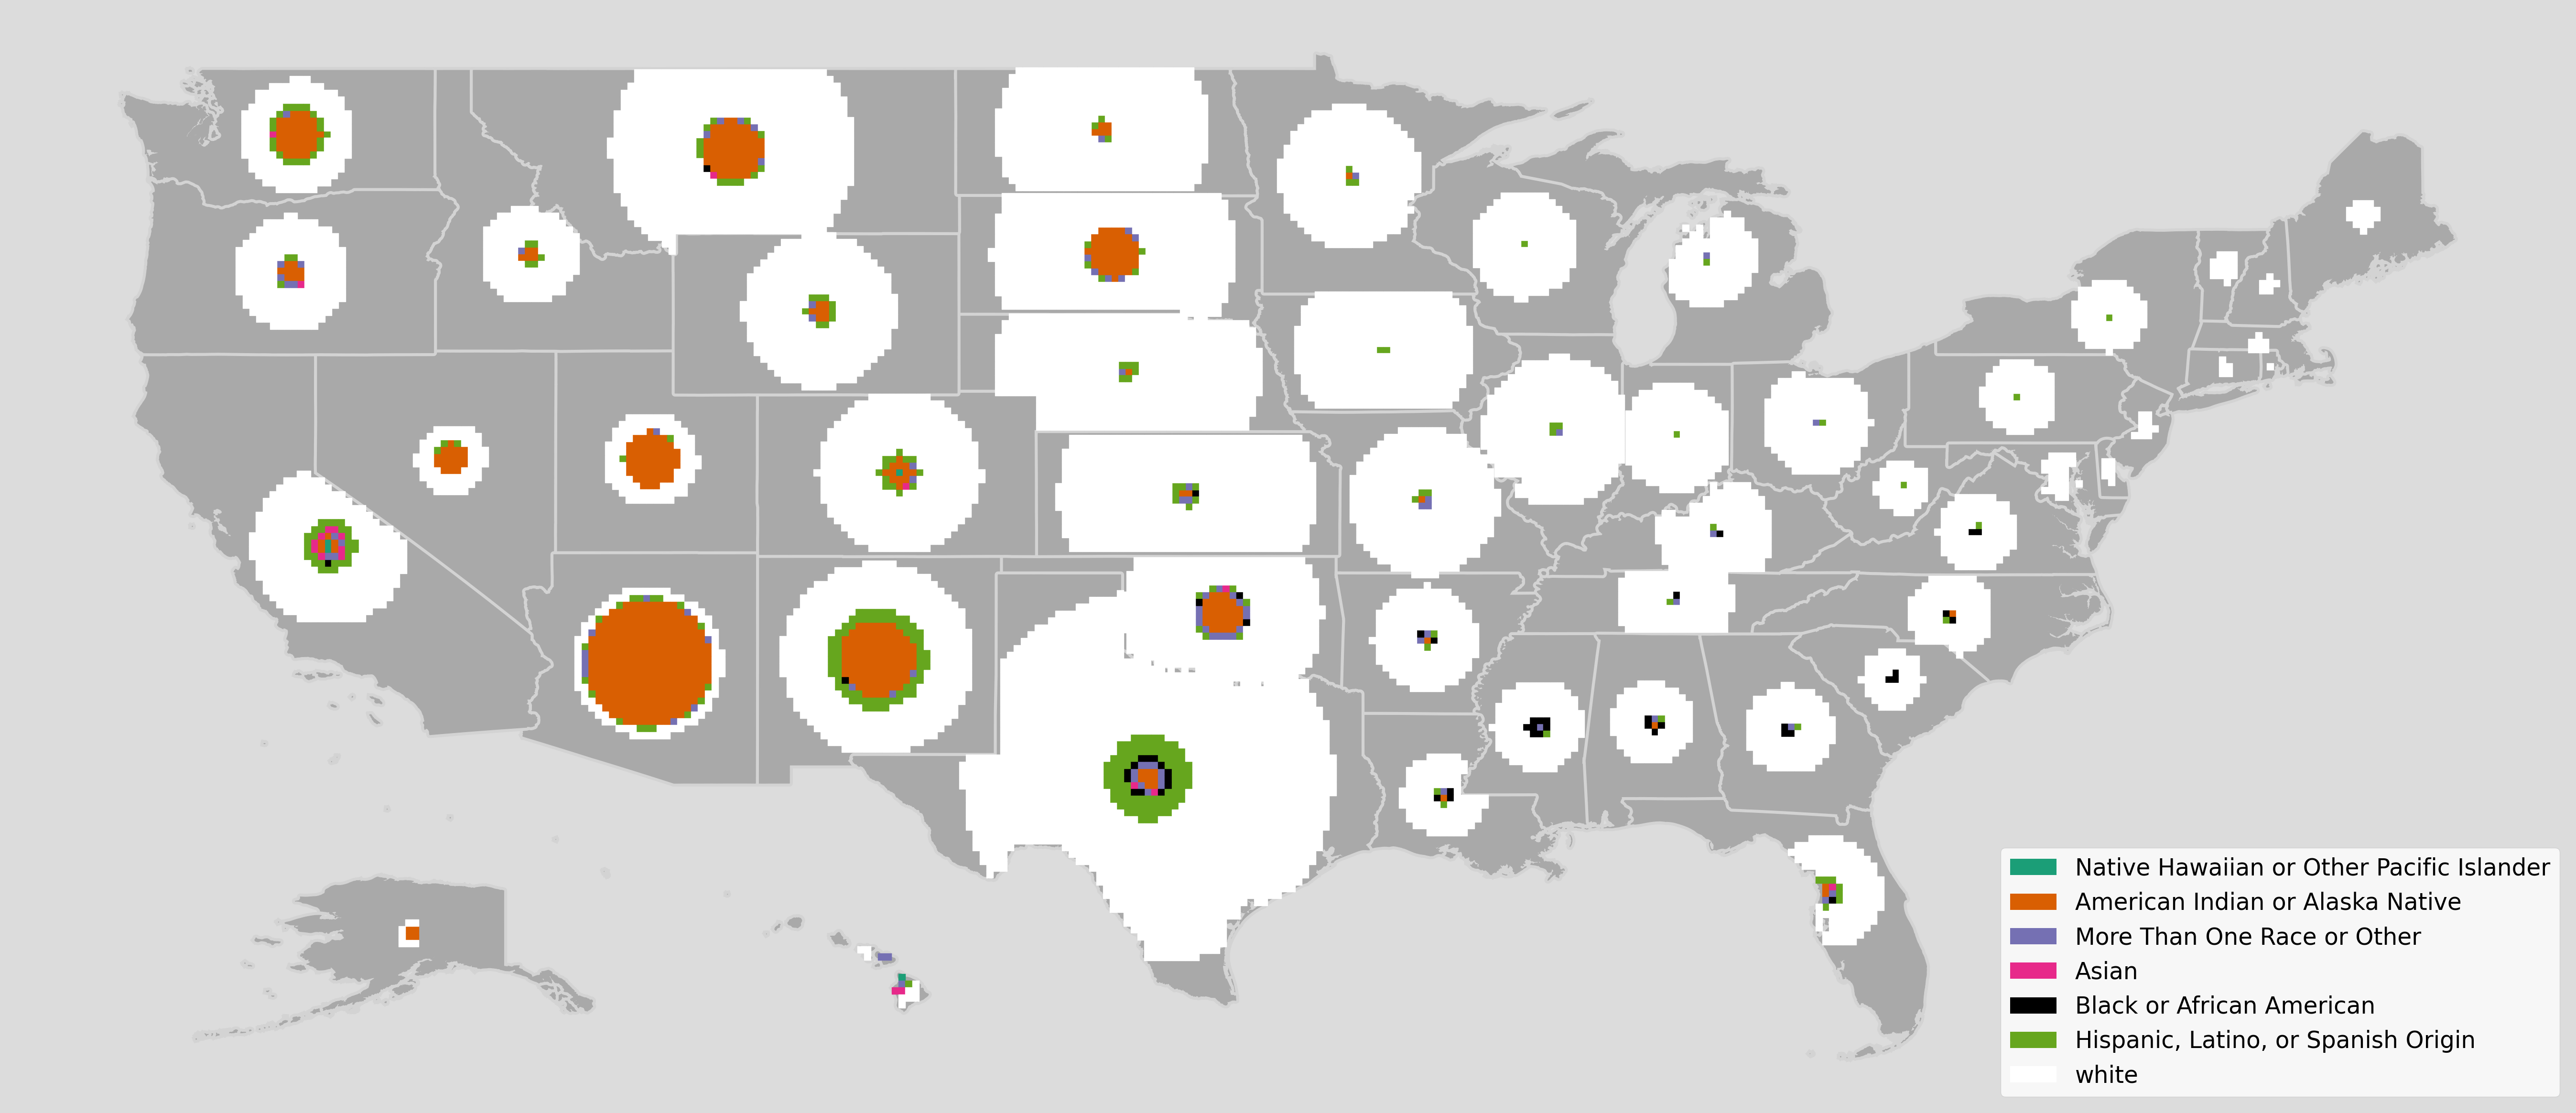

In [61]:
pt_size = 90 # point size
marker_type = "s"
lw_states = 10
c_state_fill = "darkgray"
c_state_plot = "lightgray"
face= "gainsboro"
a_state_fill = 1
a_state_plot = 1
size_mag=3

plt.figure(figsize=(18*size_mag,8*size_mag), facecolor=face)

# plot grid by color
for i in range(len(state_names)):
    print(state_names[i])
    curr_cols = state_cols[i] # get current state colors
    curr_grid_x = grid_ordered[i][0] # get current grid x points
    curr_grid_y = grid_ordered[i][1] # get current grid y points
    for j in range(len(curr_cols)):
        plt.scatter(curr_grid_x[j], curr_grid_y[j], c=curr_cols[j], marker=marker_type, s=pt_size, zorder=1)
        plt.gca().set_aspect("equal")

# plot original single states
for i in range(len(state_coords_s)):
    curr_coords = state_coords_s[i]
    plt.plot(curr_coords[0], curr_coords[1], c=c_state_plot, lw=lw_states, alpha=a_state_plot, zorder=0)
    plt.fill(curr_coords[0], curr_coords[1], c=c_state_fill, alpha=a_state_fill, zorder=0)
    plt.gca().set_aspect("equal")\

# plot original multipolygon states
for i in range(len(state_coords_m)):
    curr_coords = state_coords_m[i]
    for j in range(len(curr_coords)):
        plt.plot(curr_coords[j][0], curr_coords[j][1], c=c_state_plot, lw=lw_states, alpha=a_state_plot, zorder=0)
        plt.fill(curr_coords[j][0], curr_coords[j][1], c=c_state_fill, alpha=a_state_fill, zorder=0)
        plt.gca().set_aspect("equal")

# create legend
legend_elements = [Patch(facecolor="#1b9e77", label='Native Hawaiian or Other Pacific Islander'),
                   Patch(facecolor="#d95f02", label='American Indian or Alaska Native'),
                   Patch(facecolor="#7570b3", label='More Than One Race or Other'),
                   Patch(facecolor="#e7298a", label='Asian'),
                   Patch(facecolor="k", label='Black or African American'),
                   Patch(facecolor="#66a61e", label='Hispanic, Latino, or Spanish Origin'),
                   Patch(facecolor="white", label='white'),
                  ]

plt.legend(handles=legend_elements, loc='lower right',prop={'size': 35})
plt.axis("off")
plt.tight_layout()

plt.savefig("./OUTPUTS/FIGURE1/acres_map.png")

# Analysis of population

In [62]:
# adjust factor keeps max points for a state in bounds
adjust=0

In [63]:
# read in data
df = pd.read_csv("./USDA_maps/population_map_race_2020.csv")

# remove US data for now
df = df.iloc[1:,:]

# get the total value for each state
df["total"] = df["white"]+df["Latino"]+df["Indigenous"]+df["Asian"]+df["Black"]+df["PacificIslander"]+df["Mixed"]+df["Other"]

# add the number of points per state and value per point
temp_df = pd.DataFrame({"state":state_names, "points":grid_lens})
df = pd.merge(df,temp_df,on="state")
df["val_pt"] = df["total"]/df["points"]

# find the state with the maximum value per point
max_state = df["state"][df["val_pt"]==df["val_pt"].max()].item()
print("The max value per point state is", max_state)

# set the value per point value
# in this case: population per point
val_pt = np.round(df["val_pt"].max(),-1)-adjust
print(val_pt)

The max value per point state is New Jersey
130830.0


In [64]:
state_cols = [] # get colors of points for each state

for i in range(len(state_names)):

    curr_state=state_names[i]
    
    # get colors
    curr_df = df[df["state"]==curr_state]
    nPacific = int(np.round(((curr_df["PacificIslander"])*(1/val_pt)).item()))
    nIndigenous = int(np.round(((curr_df["Indigenous"])*(1/val_pt)).item()))
    nMixed = int(np.round(((curr_df["Mixed"])*(1/val_pt)).item()))
    nAsian = int(np.round(((curr_df["Asian"])*(1/val_pt)).item()))
    nBlack = int(np.round(((curr_df["Black"])*(1/val_pt)).item()))
    nLatino = int(np.round(((curr_df["Latino"])*(1/val_pt)).item()))
    nwhite = int(np.round(((curr_df["white"])*(1/val_pt)).item()))
    
    colors = []
    for i in range(nPacific):
        colors.append("#1b9e77") # teal
    for i in range(nIndigenous):
        colors.append("#d95f02") # orange
    for i in range(nMixed):
        colors.append("#7570b3") # purple
    for i in range(nAsian):
        colors.append("#e7298a") # magenta
    for i in range(nBlack):
        colors.append("k") # black
    for i in range(nLatino):
        colors.append("#66a61e") # green
    for i in range(nwhite):
        colors.append("white") # white

    state_cols.append(colors)

# Plot population

Oklahoma
West Virginia
Idaho
Nebraska
New Mexico
South Dakota
Pennsylvania
Missouri
Colorado
Utah
Tennessee
Wyoming
Kansas
Nevada
Illinois
Vermont
Montana
Iowa
Arizona
New Jersey
North Dakota
Arkansas
Indiana
Alaska
Hawaii
Mississippi
North Carolina
Virginia
Louisiana
Michigan
Massachusetts
Florida
Washington
Texas
California
Alabama
Georgia
New York
South Carolina
New Hampshire
Maryland
Maine
Delaware
Rhode Island
Kentucky
Ohio
Wisconsin
Oregon
Minnesota
Connecticut


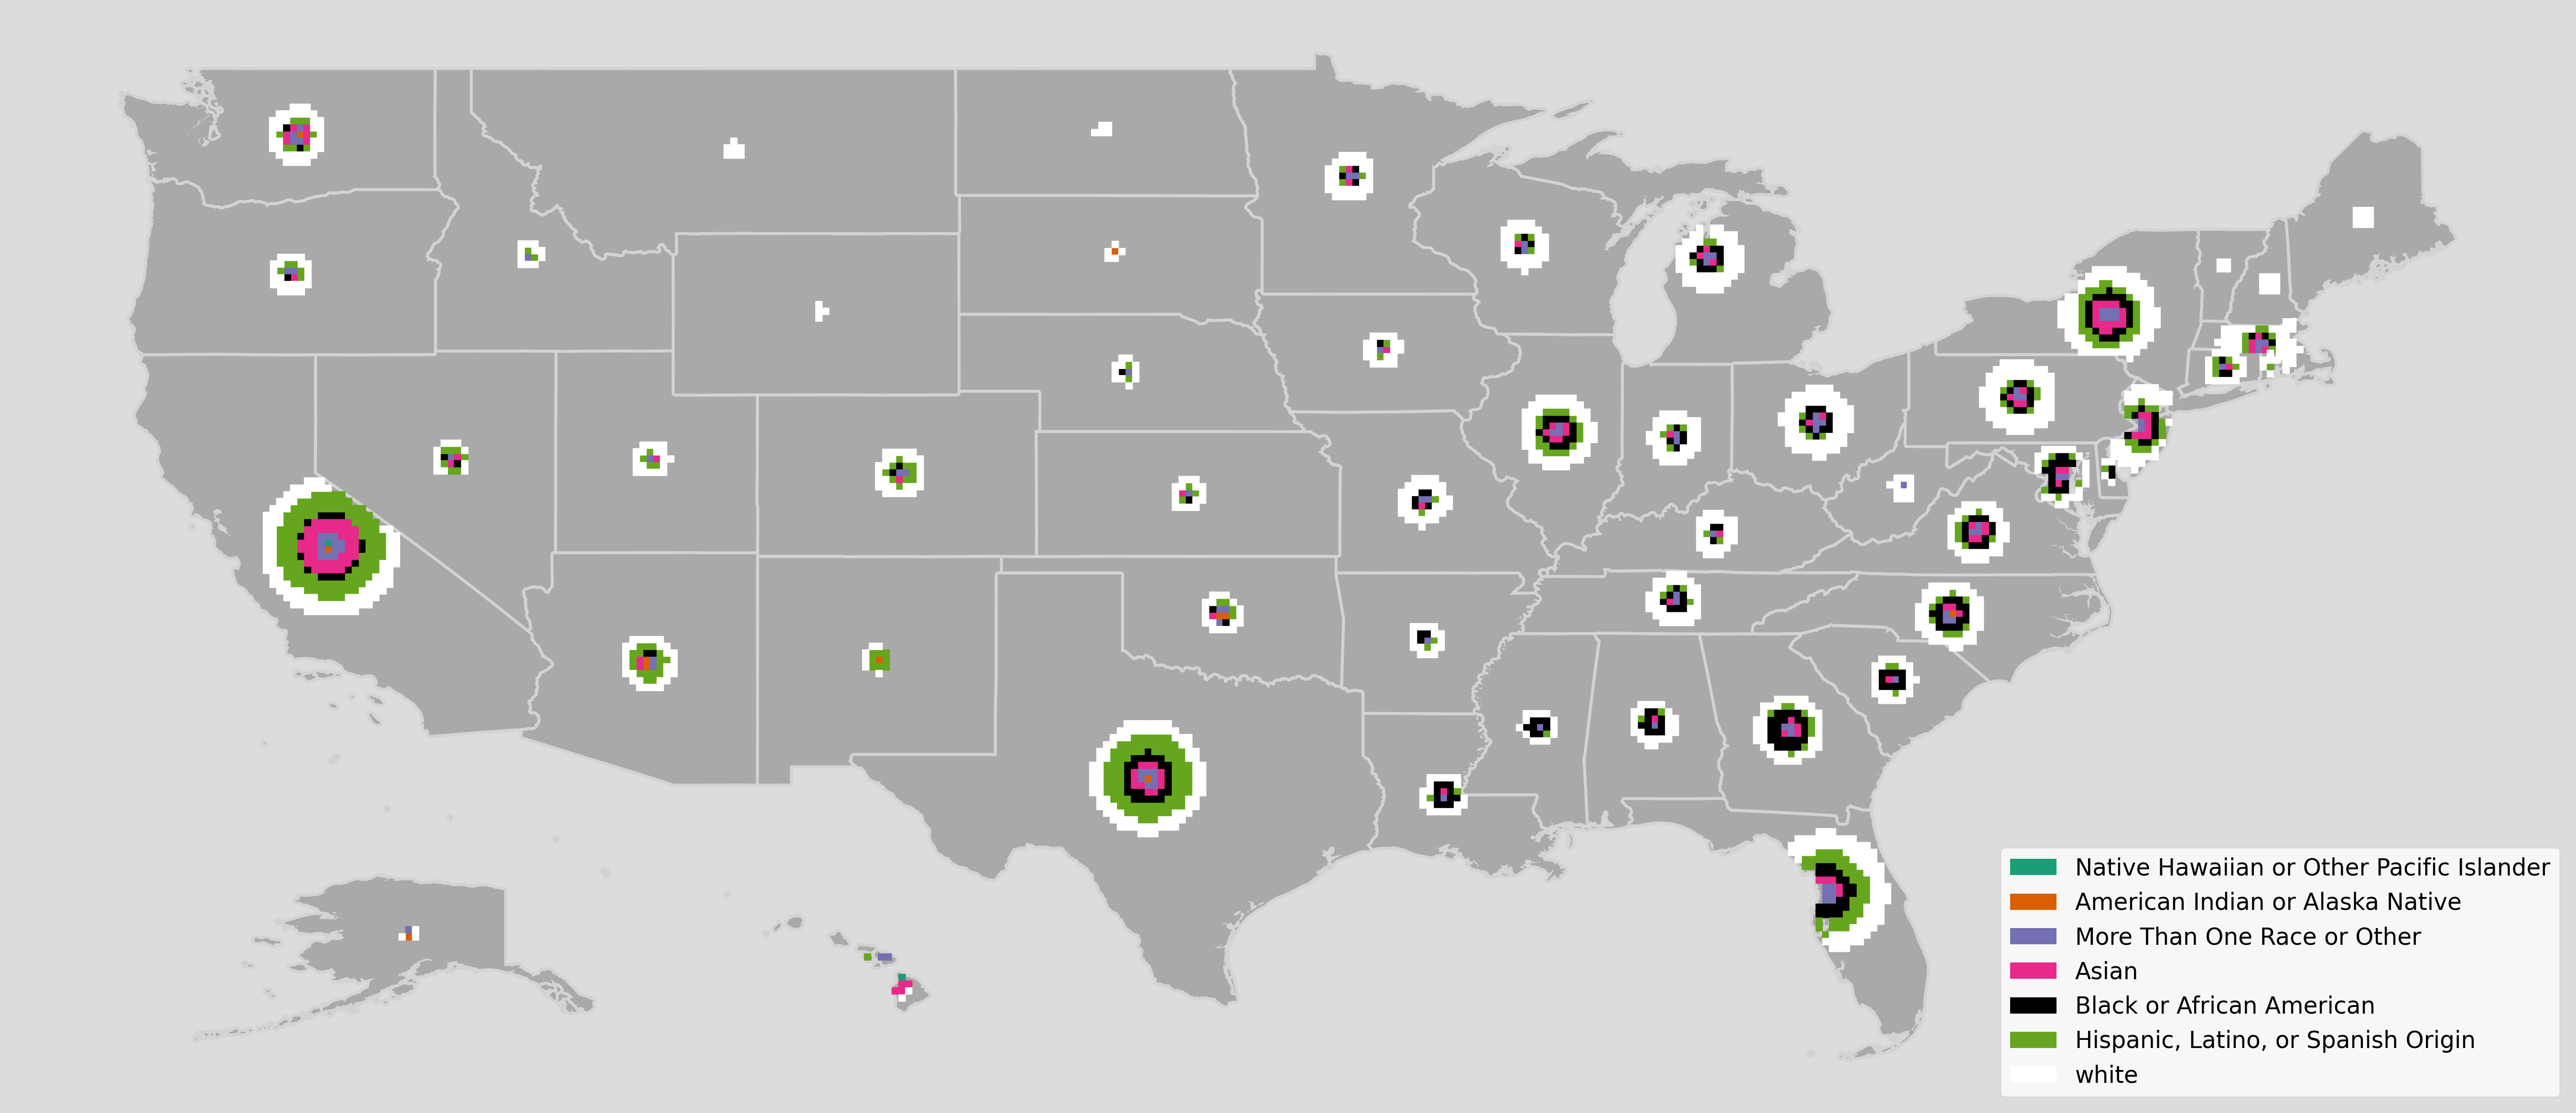

In [65]:
pt_size = 90 # point size
marker_type = "s"
lw_states = 10
c_state_fill = "darkgray"
c_state_plot = "lightgray"
face= "gainsboro"
a_state_fill = 1
a_state_plot = 1
size_mag=3

plt.figure(figsize=(18*size_mag,8*size_mag), facecolor=face)

# plot grid by color
for i in range(len(state_names)):
    print(state_names[i])
    curr_cols = state_cols[i] # get current state colors
    curr_grid_x = grid_ordered[i][0] # get current grid x points
    curr_grid_y = grid_ordered[i][1] # get current grid y points
    for j in range(len(curr_cols)):
        plt.scatter(curr_grid_x[j], curr_grid_y[j], c=curr_cols[j], marker=marker_type, s=pt_size, zorder=1)
        plt.gca().set_aspect("equal")

# plot original single states
for i in range(len(state_coords_s)):
    curr_coords = state_coords_s[i]
    plt.plot(curr_coords[0], curr_coords[1], c=c_state_plot, lw=lw_states, alpha=a_state_plot, zorder=0)
    plt.fill(curr_coords[0], curr_coords[1], c=c_state_fill, alpha=a_state_fill, zorder=0)
    plt.gca().set_aspect("equal")\

# plot original multipolygon states
for i in range(len(state_coords_m)):
    curr_coords = state_coords_m[i]
    for j in range(len(curr_coords)):
        plt.plot(curr_coords[j][0], curr_coords[j][1], c=c_state_plot, lw=lw_states, alpha=a_state_plot, zorder=0)
        plt.fill(curr_coords[j][0], curr_coords[j][1], c=c_state_fill, alpha=a_state_fill, zorder=0)
        plt.gca().set_aspect("equal")

# create legend
legend_elements = [Patch(facecolor="#1b9e77", label='Native Hawaiian or Other Pacific Islander'),
                   Patch(facecolor="#d95f02", label='American Indian or Alaska Native'),
                   Patch(facecolor="#7570b3", label='More Than One Race or Other'),
                   Patch(facecolor="#e7298a", label='Asian'),
                   Patch(facecolor="k", label='Black or African American'),
                   Patch(facecolor="#66a61e", label='Hispanic, Latino, or Spanish Origin'),
                   Patch(facecolor="white", label='white'),
                  ]

plt.legend(handles=legend_elements, loc='lower right',prop={'size': 35})
plt.axis("off")
plt.tight_layout()

plt.savefig("./OUTPUTS/FIGURE1/pop_map.png")

# American Indian Nations

In [66]:
# read in nations maps
nations = gpd.read_file("./USDA_maps/cb_2018_us_aiannh_500k/cb_2018_us_aiannh_500k.shp") # Path to the shapefile

# read in nations data
nations_data = pd.read_csv("./USDA_maps/nations_principal_acres_2017.csv")

### replace names in data so that they match map names
# the data names
data_names = ["Ak-Chin",
              "Coeur d’Alene",
              "Flandreau Santee",
              "Fort McDowell",
              "Fort Yuma-Quechan",
              "Ho-Chunk",
              "Kaibab Paiute",
              "Lac Courte Oreilles Ojibwa",
              "Mississippi Bands of Choctaw",
              "Oneida Tribe of Wisconsin",
              "Prairie Island Community",
              "Pueblo de Cochiti",
              "Pueblo of Isleta",
              "Pueblo of Jemez",
              "Pueblo of Santo Domingo" ,
              "Pueblo of Zuni",
              "Red Lake Band",
              "Rocky Boy’s" ,
              "Salt River Pima-Maricopa",
              "San Carlos Apache",
              "Santee Sioux" ,
              "Sokaogon Chippewa Community",
              "Stockbridge-Munsee",
              "Tohono O’odham",
              "Turtle Mountain/Trenton Indian Service Area",
              "Yakama" ]

# the map names
map_names = ['Maricopa (Ak Chin)',
             "Coeur d'Alene",
             'Flandreau',
             'Fort McDowell Yavapai Nation',
             'Fort Yuma',
             'Ho-Chunk Nation',
             'Kaibab',
             'Lac Courte Oreilles',
             'Mississippi Choctaw',
             'Oneida (WI)',
             'Prairie Island',
             'Cochiti',
             'Isleta',
             'Jemez',
             'San Felipe Pueblo/Santo Domingo Pueblo',
             'Zuni',
             'Red Lake',
             "Rocky Boy's",
             'Salt River',
             'San Carlos',
             'Santee',
             'Sokaogon Chippewa',
             'Stockbridge Munsee',
             "Tohono O'odham Nation",
             'Turtle Mountain',
              'Yakama Nation']   

# for each of the data names to replace
for i in range(len(data_names)):

    # get the current name to replace in data
    curr_data_name = data_names[i] 
    
    # get the index of the name in the data
    data_ind = nations_data["nation"][nations_data["nation"]==curr_data_name].index.item()
    
    # replace with the map name at the index
    nations_data["nation"].iloc[data_ind] = map_names[i]

# determine which nation maps are single or multi polygons
single_nations = [] # a list of single nation names
multi_nations = [] # a list of multi nation names

for i in range(len(nations)):

    # retrieve nation name from map data
    nation_name = nations["NAME"].iloc[i]
    
    # get the polygon type for the nation name
    nation_type = str(type(nations["geometry"].iloc[i]))
    
    if nation_type=="<class 'shapely.geometry.polygon.Polygon'>":
        single_nations.append(nation_name)
    
    if nation_type=="<class 'shapely.geometry.multipolygon.MultiPolygon'>":
        multi_nations.append(nation_name)

# Retrieve polygon nations

### Single polygon nations

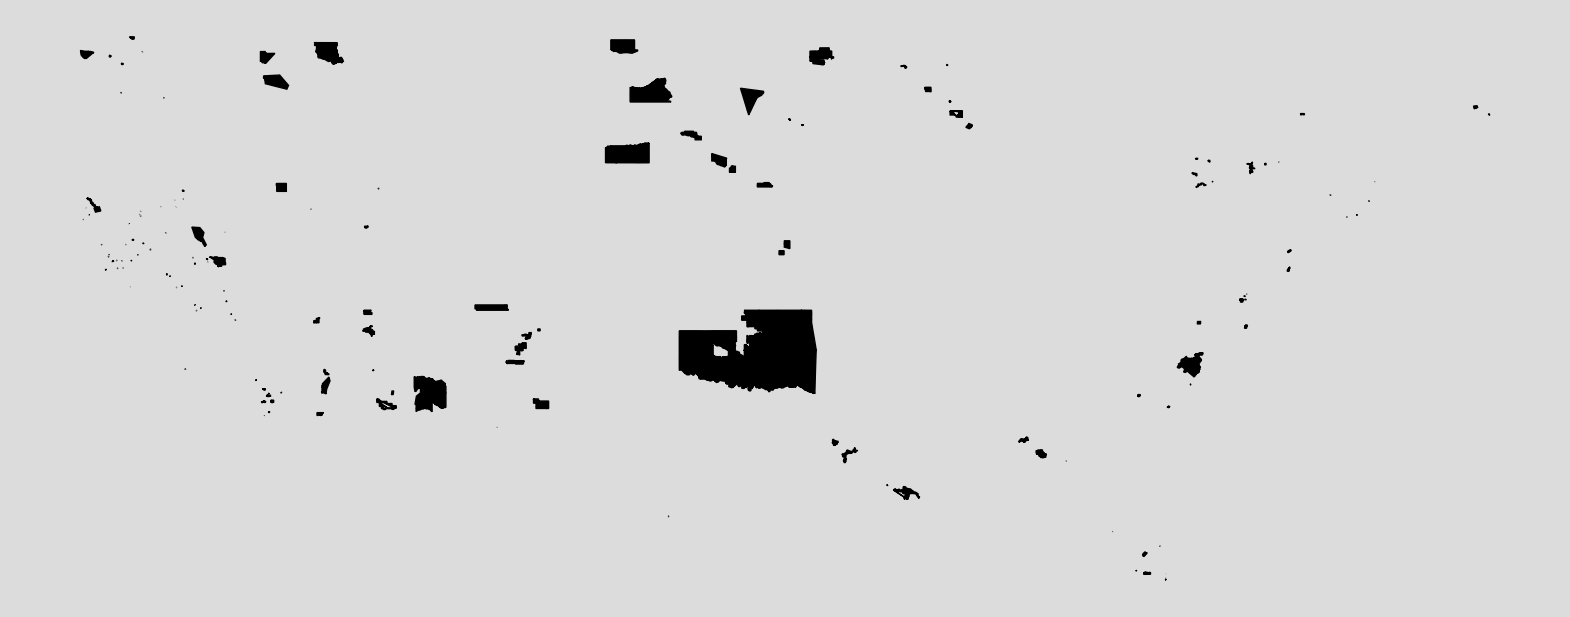

In [67]:
# info for scaling and translating Alaska
ak_long = -127
ak_lat = 50

# info for scaling and translating Hawaii
hi_long = -140
hi_lat = 23

#################
#################

nation_names_s = [] # lists to store data from single polygon nations
alaska_names_s = [] # list to store alaska names
hawaii_names_s = [] # list to store hawaii names

nation_coords_s = []
alaska_coords_s = []
hawaii_coords_s = []

nation_centroids_s = []

plt.figure(figsize=(20,18), facecolor="gainsboro")
for s in single_nations:

    #print(s)

    curr_nation=s # select current nation
    curr_coords = nations[nations["NAME"]==curr_nation].get_coordinates() # get coordinates as dataframe
    curr_coord_list = [list(curr_coords["x"]), list(curr_coords["y"])] # convert to list of lists
    
    # get centroid
    cen_x_val = (min(curr_coord_list[0])+max(curr_coord_list[0]))/2
    cen_y_val = (min(curr_coord_list[1])+max(curr_coord_list[1]))/2
    curr_centroid = [cen_x_val, cen_y_val]

    #################
    #################

    if (cen_x_val<ak_long) & (cen_y_val>ak_lat): # translate and scale Alaska
        alaska_names_s.append(curr_nation)
        alaska_coords_s.append(curr_coord_list)
        continue
        
    if (cen_x_val<hi_long) &  (cen_y_val<hi_lat): # translate and scale Hawaii
        hawaii_names_s.append(curr_nation)
        hawaii_coords_s.append(curr_coord_list)
        continue

    if curr_nation=="Santa Rosa": # problems with the map for this nation
        continue

    if curr_nation=="Santee":
        xvals = []
        yvals = []
        for i in range(len(curr_coord_list[0])):
            if curr_coord_list[0][i]<-90:
                xvals.append(curr_coord_list[0][i])
                yvals.append(curr_coord_list[1][i])
        curr_coord_list = [xvals, yvals]
                
    #################
    #################

    # save data
    nation_names_s.append(curr_nation)
    nation_coords_s.append(curr_coord_list)
    nation_centroids_s.append(curr_centroid)
    
    # check plot
    plt.fill(curr_coord_list[0], curr_coord_list[1], c="k")
    #plt.plot(curr_coord_list[0], curr_coord_list[1])
    #plt.scatter(curr_centroid[0], curr_centroid[1])
    plt.gca().set_aspect("equal")
    plt.axis("off")


### Multipolygon nations

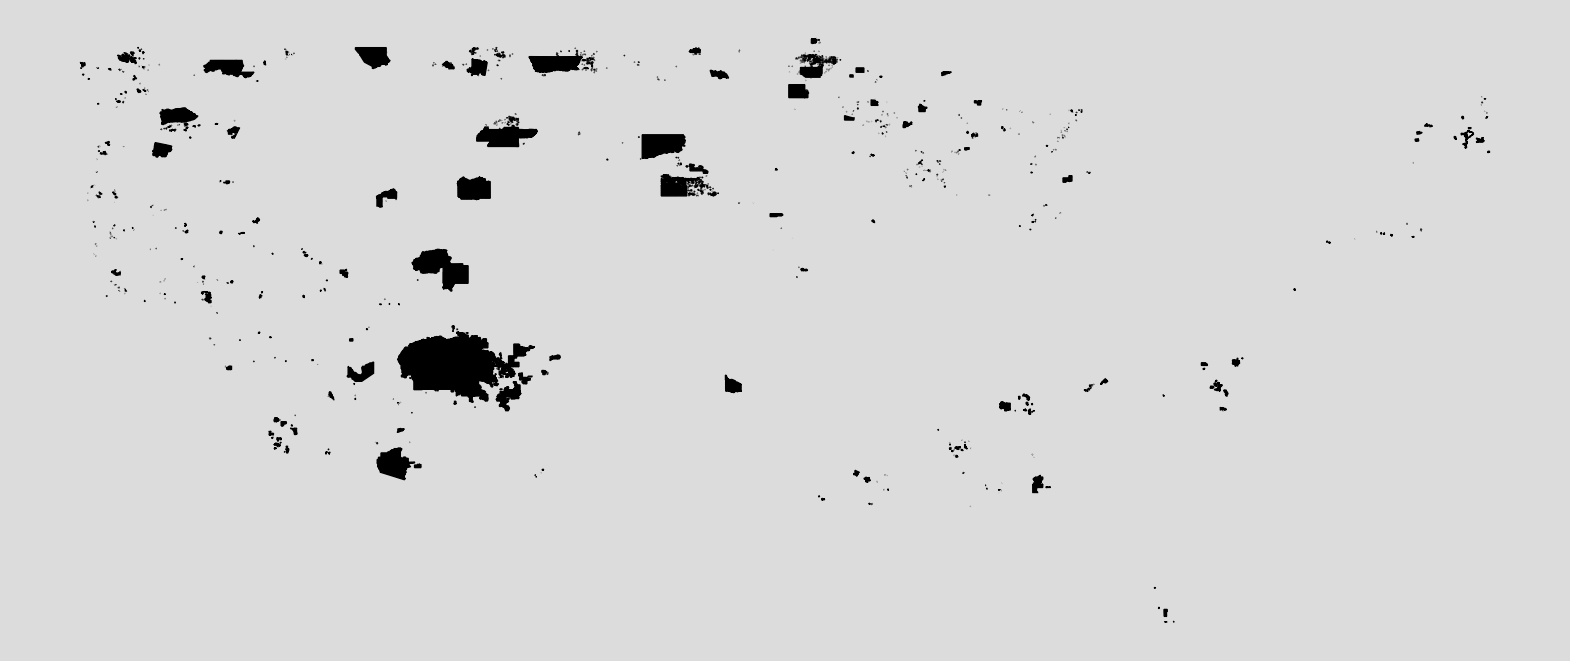

In [68]:
# info for scaling and translating Alaska
ak_long = -127
ak_lat = 50

# info for scaling and translating Hawaii
hi_long = -140
hi_lat = 23

################

nation_names_m = [] # lists to store data from multipolygon nations
alaska_names_m = [] # list to store alaska names
hawaii_names_m = [] # list to store hawaii names

nation_coords_m = []
alaska_coords_m = []
hawaii_coords_m = []

nation_centroids_m = []

plt.figure(figsize=(20,18), facecolor="gainsboro")
for m in multi_nations:

    curr_nation=m # select current nation
    if curr_nation=="Santa Rosa": # problems with the map for this nation
        continue

    #print(curr_nation)

    curr_df = nations[nations["NAME"]==curr_nation] # get coordinates as dataframe

    # expand polygons
    polys = (
        gpd.GeoSeries(
            curr_df.dropna()["geometry"].apply(lambda g: g.geoms).explode()
        )
        .reset_index(drop=True)
    )
    
    # get coordinates for each polygon
    curr_coords = []
    for geom in polys:
        curr_coords.append(list(geom.exterior.coords))
    
    # unzip coordinates and create list of list of coordinates
    curr_coord_list = []
    for i in range(len(curr_coords)):
        unzipped_coord = list(zip(*curr_coords[i]))
        unzipped_list = [list(unzipped_coord)[0],list(unzipped_coord)[1]]
        curr_coord_list.append(unzipped_list)
    
    # calcualte the centroid of bounding box
    cen_x_vals = []
    cen_y_vals = []
    for i in range(len(curr_coord_list)):
        for j in range(len(curr_coord_list[i][0])):
            cen_x_vals.append(curr_coord_list[i][0][j])
        for k in range(len(curr_coord_list[i][1])):
            cen_y_vals.append(curr_coord_list[i][1][k])
    cen_x_val = (min(cen_x_vals)+max(cen_x_vals))/2
    cen_y_val = (min(cen_y_vals)+max(cen_y_vals))/2
    curr_centroid = [cen_x_val, cen_y_val]
    
    #################
    #################

    if (cen_x_val<ak_long) & (cen_y_val>ak_lat): # translate and scale Alaska
        alaska_names_m.append(curr_nation)
        alaska_coords_m.append(curr_coord_list)
        continue

    if (cen_x_val<hi_long) &  (cen_y_val<hi_lat): # translate and scale Hawaii
        hawaii_names_m.append(curr_nation)
        hawaii_coords_m.append(curr_coord_list)
        continue

    #################
    #################

    # save data
    nation_names_m.append(curr_nation)
    nation_coords_m.append(curr_coord_list)
    nation_centroids_m.append(curr_centroid)
        
    # check plot
    for i in range(len(curr_coord_list)):
        plt.fill(curr_coord_list[i][0], curr_coord_list[i][1], c="k")
        #plt.scatter(curr_centroid[0], curr_centroid[1], s=0.1)
        plt.gca().set_aspect("equal")
        plt.axis("off")

### Alaska and Hawaii nations

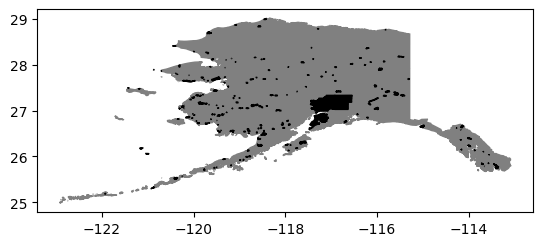

In [69]:
# info for scaling and translating Alaska
ak_scale=0.2
ak_xval = -118 # destination values
ak_yval = 27
ak_centroid_x = ak_centroid[0]
ak_centroid_y = ak_centroid[1]

new_ak_coords_s = []

for i in range(len(alaska_names_s)):

    curr_coords = alaska_coords_s[i]

    zero_x = np.array(curr_coords[0])-ak_centroid_x
    zero_y = np.array(curr_coords[1])-ak_centroid_y

    scale_x = zero_x*ak_scale
    scale_y = zero_y*ak_scale

    new_x = scale_x+ak_xval
    new_y = scale_y+ak_yval

    new_ak_coords_s.append([list(new_x), list(new_y)])

new_ak_coords_m = []

for i in range(len(alaska_names_m)):

    curr_multi_coords = alaska_coords_m[i]

    new_multi_coords = []
    for j in range(len(curr_multi_coords)):

        curr_coords = curr_multi_coords[j]

        zero_x = np.array(curr_coords[0])-ak_centroid_x
        zero_y = np.array(curr_coords[1])-ak_centroid_y
    
        scale_x = zero_x*ak_scale
        scale_y = zero_y*ak_scale
    
        new_x = scale_x+ak_xval
        new_y = scale_y+ak_yval

        new_multi_coords.append([list(new_x), list(new_y)])

    new_ak_coords_m.append(new_multi_coords)

for i in range(len(new_ak_coords_s)):
    plt.fill(new_ak_coords_s[i][0], new_ak_coords_s[i][1], c="k")
    plt.gca().set_aspect("equal")
    plt.axis("on")

for i in range(len(new_ak_coords_m)):
    multi_coords = new_ak_coords_m[i]
    for j in range(len(multi_coords)):
        plt.fill(multi_coords[j][0], multi_coords[j][1], c="k")
        plt.gca().set_aspect("equal")
        plt.axis("on")

for i in range(len(state_coords_m[0])):
    plt.fill(state_coords_m[0][i][0], state_coords_m[0][i][1], c="gray", zorder=0)
    plt.gca().set_aspect("equal")
    plt.axis("on")

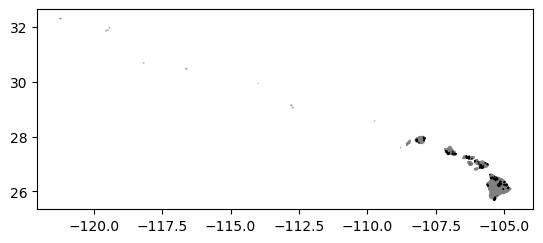

In [70]:
# info for scaling and translating Hawaii
hi_scale=0.7
hi_xval = -113 # destination values
hi_yval = 29
hi_centroid_x = hi_centroid[0]
hi_centroid_y = hi_centroid[1]

new_hi_coords_s = []

for i in range(len(hawaii_names_s)):

    curr_coords = hawaii_coords_s[i]

    zero_x = np.array(curr_coords[0])-hi_centroid_x
    zero_y = np.array(curr_coords[1])-hi_centroid_y

    scale_x = zero_x*hi_scale
    scale_y = zero_y*hi_scale

    new_x = scale_x+hi_xval
    new_y = scale_y+hi_yval

    new_hi_coords_s.append([list(new_x), list(new_y)])

new_hi_coords_m = []

for i in range(len(hawaii_names_m)):

    curr_multi_coords = hawaii_coords_m[i]

    new_multi_coords = []
    for j in range(len(curr_multi_coords)):

        curr_coords = curr_multi_coords[j]

        zero_x = np.array(curr_coords[0])-hi_centroid_x
        zero_y = np.array(curr_coords[1])-hi_centroid_y
    
        scale_x = zero_x*hi_scale
        scale_y = zero_y*hi_scale
    
        new_x = scale_x+hi_xval
        new_y = scale_y+hi_yval

        new_multi_coords.append([list(new_x), list(new_y)])

    new_hi_coords_m.append(new_multi_coords)

for i in range(len(new_hi_coords_s)):
    plt.fill(new_hi_coords_s[i][0], new_hi_coords_s[i][1], c="k")
    plt.gca().set_aspect("equal")
    plt.axis("on")

for i in range(len(new_hi_coords_m)):
    multi_coords = new_hi_coords_m[i]
    for j in range(len(multi_coords)):
        plt.fill(multi_coords[j][0], multi_coords[j][1], c="k")
        plt.gca().set_aspect("equal")
        plt.axis("on")

for i in range(len(state_coords_m[1])):
    plt.fill(state_coords_m[1][i][0], state_coords_m[1][i][1], c="gray", zorder=0)
    plt.gca().set_aspect("equal")
    plt.axis("on")

### Plot single and multi nations to check

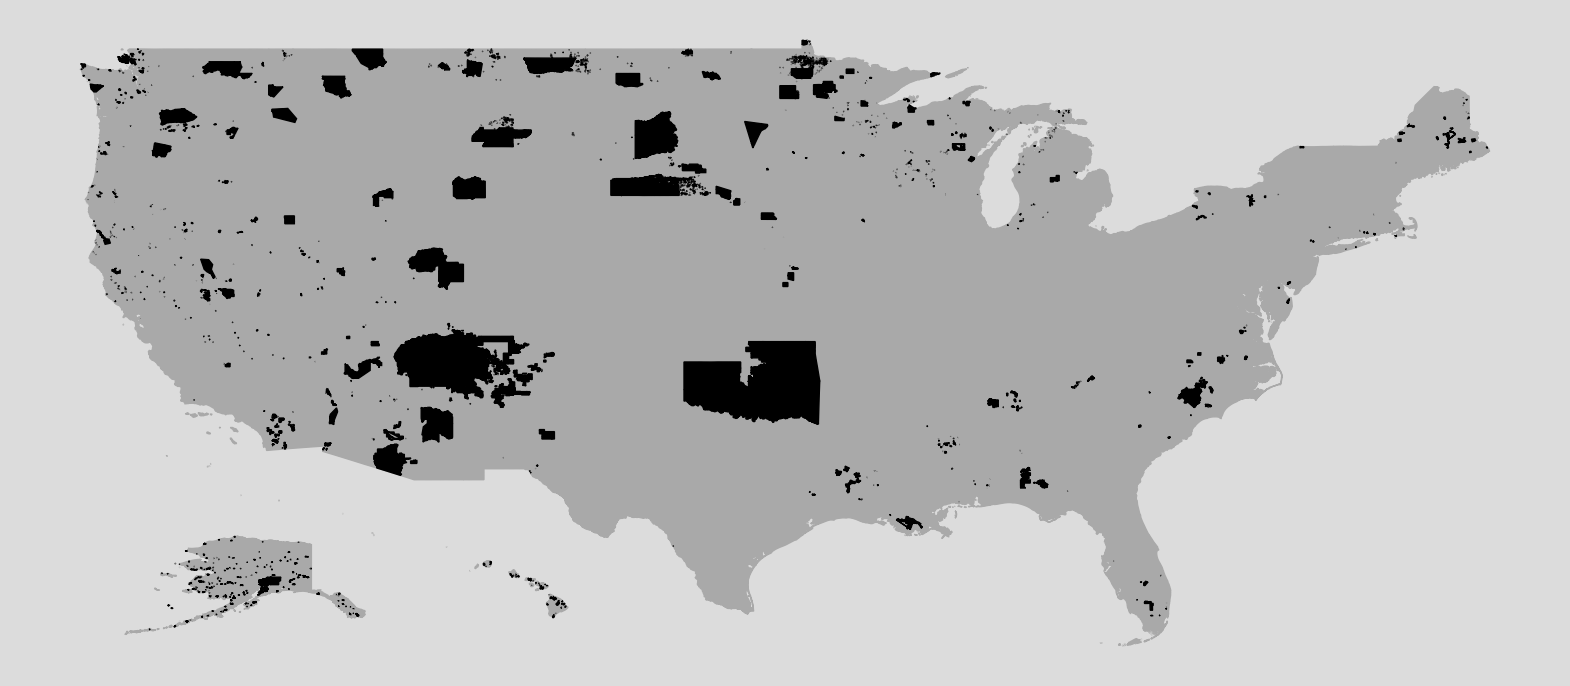

In [71]:
plt.figure(figsize=(20,18), facecolor="gainsboro")
# plot single nations
for i in range(len(nation_names_s)):
    plt.fill(nation_coords_s[i][0], nation_coords_s[i][1], c="k")
    plt.gca().set_aspect("equal")
    plt.axis("off")

# plot multi nations
for i in range(len(nation_names_m)):
    for j in range(len(nation_coords_m[i])):
        plt.fill(nation_coords_m[i][j][0], nation_coords_m[i][j][1], c="k")
        plt.gca().set_aspect("equal")
        plt.axis("off")

# plot single alaska
for i in range(len(new_ak_coords_s)):
    plt.fill(new_ak_coords_s[i][0], new_ak_coords_s[i][1], c="k")
    plt.gca().set_aspect("equal")
    plt.axis("off")

# plot multi alaska
for i in range(len(new_ak_coords_m)):
    multi_coords = new_ak_coords_m[i]
    for j in range(len(multi_coords)):
        plt.fill(multi_coords[j][0], multi_coords[j][1], c="k")
        plt.gca().set_aspect("equal")
        plt.axis("off")

# plot single hawaii
for i in range(len(new_hi_coords_s)):
    plt.fill(new_hi_coords_s[i][0], new_hi_coords_s[i][1], c="k")
    plt.gca().set_aspect("equal")
    plt.axis("off")

# plot multi hawaii
for i in range(len(new_hi_coords_m)):
    multi_coords = new_hi_coords_m[i]
    for j in range(len(multi_coords)):
        plt.fill(multi_coords[j][0], multi_coords[j][1], c="k")
        plt.gca().set_aspect("equal")
        plt.axis("off")

# plot original single states
for i in range(len(state_coords_s)):
    curr_coords = state_coords_s[i]
    #plt.plot(curr_coords[0], curr_coords[1], c=c_state_plot, lw=lw_states, alpha=a_state_plot, zorder=0)
    plt.fill(curr_coords[0], curr_coords[1], c=c_state_fill, alpha=a_state_fill, zorder=0)
    plt.gca().set_aspect("equal")

# plot original multipolygon states
for i in range(len(state_coords_m)):
    curr_coords = state_coords_m[i]
    for j in range(len(curr_coords)):
        #plt.plot(curr_coords[j][0], curr_coords[j][1], c=c_state_plot, lw=lw_states, alpha=a_state_plot, zorder=0)
        plt.fill(curr_coords[j][0], curr_coords[j][1], c=c_state_fill, alpha=a_state_fill, zorder=0)
        plt.gca().set_aspect("equal")

# Get Nations grid points

In [72]:
#################################
#################################
#################################
# SET THE STEP VALUE FOR THE GRID
step = 0.17
#################################
#################################
#################################

### Single nation grid

In [73]:
nation_grid_s = []

for i in range(len(nation_names_s)):

    print(nation_names_s[i])

    curr_coords_x = nation_coords_s[i][0]
    curr_coords_y = nation_coords_s[i][1]

    # create grid of points
    minx = min(curr_coords_x)
    maxx = max(curr_coords_x)
    miny = min(curr_coords_y)
    maxy = max(curr_coords_y) 
    x_range = np.arange(minx, maxx, step)
    y_range = np.arange(miny, maxy, step)
    grid_x = []
    grid_y = []
    for i in x_range:
        for j in y_range:
            grid_x.append(i)
            grid_y.append(j)
    
    # create shapely polygon
    sh_poly = []
    for i in range(len(curr_coords_x)):
        sh_poly.append( (curr_coords_x[i],curr_coords_y[i]) )
    poly_s = Polygon(sh_poly)
    
    # retrieve points in shapely polygon
    x_points = []
    y_points = []
    for i in range(len(grid_x)):
        pt = Point(grid_x[i], grid_y[i])
        if poly_s.contains(pt):
            x_points.append(grid_x[i])
            y_points.append(grid_y[i])
        else:
            continue

    # save the grid points
    nation_grid_s.append([x_points, y_points])

Cedarville
Yurok
Skull Valley
Lone Pine
Schaghticoke
Sappony
Choctaw
Cheyenne-Arapaho
Likely
Jamul
Dry Creek
Lookout
Greenville
Lytton
Resighini
Grindstone
Paucatuck Eastern Pequot
Immokalee
Augustine
Ohkay Owingeh
Wells
Creek
Sac and Fox
Kickapoo
Pawnee
Seminole
Santee
Fort McDowell Yavapai Nation
San Manuel
Mechoopda
Red Cliff
Cochiti
Yerington
Poospatuck
Cowlitz
Montgomery Creek
Santa Ynez
Seminole (FL)
Mattaponi
San Carlos
Kiowa-Comanche-Apache-Fort Sill Apache
Standing Rock
Havasupai
Mooretown
Table Bluff
Coyote Valley
United Houma Nation
Hassanamisco
Fort Sill Apache
San Felipe Pueblo/Santa Ana Pueblo
Cayuga Nation
Citizen Potawatomi Nation-Absentee Shawnee
Northwestern Shoshone
Celilo
Yankton
Middletown
Apache Choctaw
Carson
Cherokee
Viejas
Big Bend
Tama
Leech Lake
Coconut Creek
Oneida Nation
Waccamaw
Star Muskogee Creek
Fort Apache
Chickasaw
Laytonville
Big Valley
Alturas
Lovelock
Kiowa-Comanche-Apache-Ft Sill Apache/Caddo-Wichita-Delaware
Cher-O-Creek
Colorado River
Four Winds

### Multi nation grid

In [74]:
nation_grid_m = []

for i in range(len(nation_names_m)):

    print(nation_names_m[i])

    curr_m_nation_coords = nation_coords_m[i]

    x_polys = [] # save polygons
    y_polys = [] 
    for j in range(len(curr_m_nation_coords)): # for each polygon 
        curr_poly = curr_m_nation_coords[j]
        x_polys.append(curr_poly[0]) # save the current poly
        y_polys.append(curr_poly[1])
        
    # flatten polygons to find min and max for grid
    flat_x = []
    flat_y = []
    for k in range(len(x_polys)):
        curr_xpoly = x_polys[k]
        curr_ypoly = y_polys[k]
        for l in range(len(curr_xpoly)):
            flat_x.append(curr_xpoly[l])
            flat_y.append(curr_ypoly[l])

    # create grid of points
    minx = min(flat_x)
    maxx = max(flat_x)
    miny = min(flat_y)
    maxy = max(flat_y) 
    x_range = np.arange(minx, maxx, step)
    y_range = np.arange(miny, maxy, step)
    grid_x = []
    grid_y = []
    for m in x_range:
        for n in y_range:
            grid_x.append(m)
            grid_y.append(n)

    # create shapely multipolygon
    multi_list = [] # list of Polygons for MultiPolygon
    for o in range(len(x_polys)):

        curr_xpoly = x_polys[o]
        curr_ypoly = y_polys[o]
        
        sh_poly = []
        for p in range(len(curr_xpoly)):
            sh_poly.append( (curr_xpoly[p],curr_ypoly[p]) )
            
        poly_m = Polygon(sh_poly)
        multi_list.append(poly_m)
        
    multi_poly = MultiPolygon(multi_list)

    # retrieve points in shapely polygon
    x_points = []
    y_points = []
    for q in range(len(grid_x)):
        pt = Point(grid_x[q], grid_y[q])
        if multi_poly.contains(pt):
            x_points.append(grid_x[q])
            y_points.append(grid_y[q])
        else:
            continue

    # save the grid points
    nation_grid_m.append([x_points, y_points])

North Fork
Rohnerville
Shoalwater Bay
Sauk-Suiattle
Wind River
Cherokee Tribe of Northeast Alabama
MOWA Choctaw
Hopi
Uintah and Ouray
Inaja and Cosmit
Fort Hall
Adais Caddo
Red Lake
Fallon Paiute-Shoshone
Coharie
Haliwa-Saponi
Warm Springs
Enterprise
Guidiville
Upper Lake
XL Ranch
Rocky Boy's
Blackfeet
Taos
Winnemucca
Colville
Spokane
MaChis Lower Creek
Echota Cherokee
Fort Mojave
Grand Portage
Jicarilla Apache Nation
Yavapai-Apache Nation
Hualapai
Fort Peck
Caddo-Wichita-Delaware
Cheyenne River
Lac Courte Oreilles
Navajo Nation
Spirit Lake
Port Gamble
Smith River
Cocopah
Passamaquoddy
Minnesota Chippewa
White Earth
Rosebud
Puyallup
Woodfords
Ewiiaapaayp
Golden Hill Paugussett
Mohegan
Miccosukee
Iowa (KS-NE)
L'Anse
Karuk
Round Valley
Sycuan
Sherwood Valley
Robinson
Prairie Island
Winnebago
Timbi-Sha Shoshone
Big Pine
Mesa Grande
Narragansett
Cow Creek
Penobscot
Jemez
Ramapough
Berry Creek
Fallon Paiute-Shoshone
Elko
Waccamaw Siouan
Zuni
Jamestown S'Klallam
Muckleshoot
Mille Lacs
Bay Mi

### Set order of nation grid points

In [75]:
nation_names = nation_names_s + nation_names_m
nation_grid = nation_grid_s + nation_grid_m

In [76]:
grid_lens = [] # store the length of each grid
grid_ordered = [] # store the ordered coords for each grid

for i in range(len(nation_names)):

    curr_nation=nation_names[i]
    print(curr_nation)
    
    curr_grid = nation_grid[i]
    curr_grid_x = curr_grid[0]
    curr_grid_y = curr_grid[1]

    if len(curr_grid_x)==0:
        grid_lens.append(0)
        grid_ordered.append([])
        continue
    
    mean_grid_x = sum(curr_grid_x)/len(curr_grid_x)
    mean_grid_y = sum(curr_grid_y)/len(curr_grid_y)
    
    dists = []
    for j in range(len(curr_grid_x)):
        dists.append(np.sqrt((curr_grid_x[j]-mean_grid_x)**2 + (curr_grid_y[j]-mean_grid_y)**2))
    
    indices = np.argsort(dists)
    grid_lens.append(len(indices))
    
    grid_x = []
    grid_y = []
    for k in indices:
        grid_x.append(curr_grid_x[k])
        grid_y.append(curr_grid_y[k])
    
    grid_ordered.append([grid_x, grid_y])
    

Cedarville
Yurok
Skull Valley
Lone Pine
Schaghticoke
Sappony
Choctaw
Cheyenne-Arapaho
Likely
Jamul
Dry Creek
Lookout
Greenville
Lytton
Resighini
Grindstone
Paucatuck Eastern Pequot
Immokalee
Augustine
Ohkay Owingeh
Wells
Creek
Sac and Fox
Kickapoo
Pawnee
Seminole
Santee
Fort McDowell Yavapai Nation
San Manuel
Mechoopda
Red Cliff
Cochiti
Yerington
Poospatuck
Cowlitz
Montgomery Creek
Santa Ynez
Seminole (FL)
Mattaponi
San Carlos
Kiowa-Comanche-Apache-Fort Sill Apache
Standing Rock
Havasupai
Mooretown
Table Bluff
Coyote Valley
United Houma Nation
Hassanamisco
Fort Sill Apache
San Felipe Pueblo/Santa Ana Pueblo
Cayuga Nation
Citizen Potawatomi Nation-Absentee Shawnee
Northwestern Shoshone
Celilo
Yankton
Middletown
Apache Choctaw
Carson
Cherokee
Viejas
Big Bend
Tama
Leech Lake
Coconut Creek
Oneida Nation
Waccamaw
Star Muskogee Creek
Fort Apache
Chickasaw
Laytonville
Big Valley
Alturas
Lovelock
Kiowa-Comanche-Apache-Ft Sill Apache/Caddo-Wichita-Delaware
Cher-O-Creek
Colorado River
Four Winds

### Get colors of nation grid points

In [77]:
# set acres per point as previously for state
val_pt = 75000

In [78]:
# read in data
nations_df = pd.read_csv("./USDA_maps/nations_principal_acres_2017.csv")

### replace names in data so that they match map names
# the data names
data_names = ["Ak-Chin",
              "Coeur d’Alene",
              "Flandreau Santee",
              "Fort McDowell",
              "Fort Yuma-Quechan",
              "Ho-Chunk",
              "Kaibab Paiute",
              "Lac Courte Oreilles Ojibwa",
              "Mississippi Bands of Choctaw",
              "Oneida Tribe of Wisconsin",
              "Prairie Island Community",
              "Pueblo de Cochiti",
              "Pueblo of Isleta",
              "Pueblo of Jemez",
              "Pueblo of Santo Domingo" ,
              "Pueblo of Zuni",
              "Red Lake Band",
              "Rocky Boy’s" ,
              "Salt River Pima-Maricopa",
              "San Carlos Apache",
              "Santee Sioux" ,
              "Sokaogon Chippewa Community",
              "Stockbridge-Munsee",
              "Tohono O’odham",
              "Turtle Mountain/Trenton Indian Service Area",
              "Yakama" ]

# the map names
map_names = ['Maricopa (Ak Chin)',
             "Coeur d'Alene",
             'Flandreau',
             'Fort McDowell Yavapai Nation',
             'Fort Yuma',
             'Ho-Chunk Nation',
             'Kaibab',
             'Lac Courte Oreilles',
             'Mississippi Choctaw',
             'Oneida (WI)',
             'Prairie Island',
             'Cochiti',
             'Isleta',
             'Jemez',
             'San Felipe Pueblo/Santo Domingo Pueblo',
             'Zuni',
             'Red Lake',
             "Rocky Boy's",
             'Salt River',
             'San Carlos',
             'Santee',
             'Sokaogon Chippewa',
             'Stockbridge Munsee',
             "Tohono O'odham Nation",
             'Turtle Mountain',
              'Yakama Nation']   

# for each of the data names to replace
for i in range(len(data_names)):

    # get the current name to replace in data
    curr_data_name = data_names[i] 
    
    # get the index of the name in the data
    data_ind = nations_df["nation"][nations_df["nation"]==curr_data_name].index.item()
    
    # replace with the map name at the index
    nations_df["nation"].iloc[data_ind] = map_names[i]

# add the number of points per nation and value per point
temp_df = pd.DataFrame({"nation":nation_names, "grid_points":grid_lens})
new_df = pd.merge(nations_df,temp_df,on="nation")

# drop the double entry for Santee
new_df.drop(new_df.iloc[[45,56]].index, inplace=True)
new_df.reset_index(drop=True, inplace=True)

# calculate data points
new_df["data_pt"] = np.round(new_df["acres"]/val_pt, 0)

# check that data points does not exceed grid points
new_df["difference"] = new_df["grid_points"]-new_df["data_pt"]

In [79]:
nation_cols = [] # get colors of points for each state
for i in range(len(new_df["nation"])):

    curr_nation=new_df["nation"].iloc[i]
    
    # get colors
    curr_df = new_df[new_df["nation"]==curr_nation]
    number = int(curr_df["data_pt"].item())
    
    colors = []
    for i in range(number):
        colors.append("#d95f02") # orange

    nation_cols.append(colors)

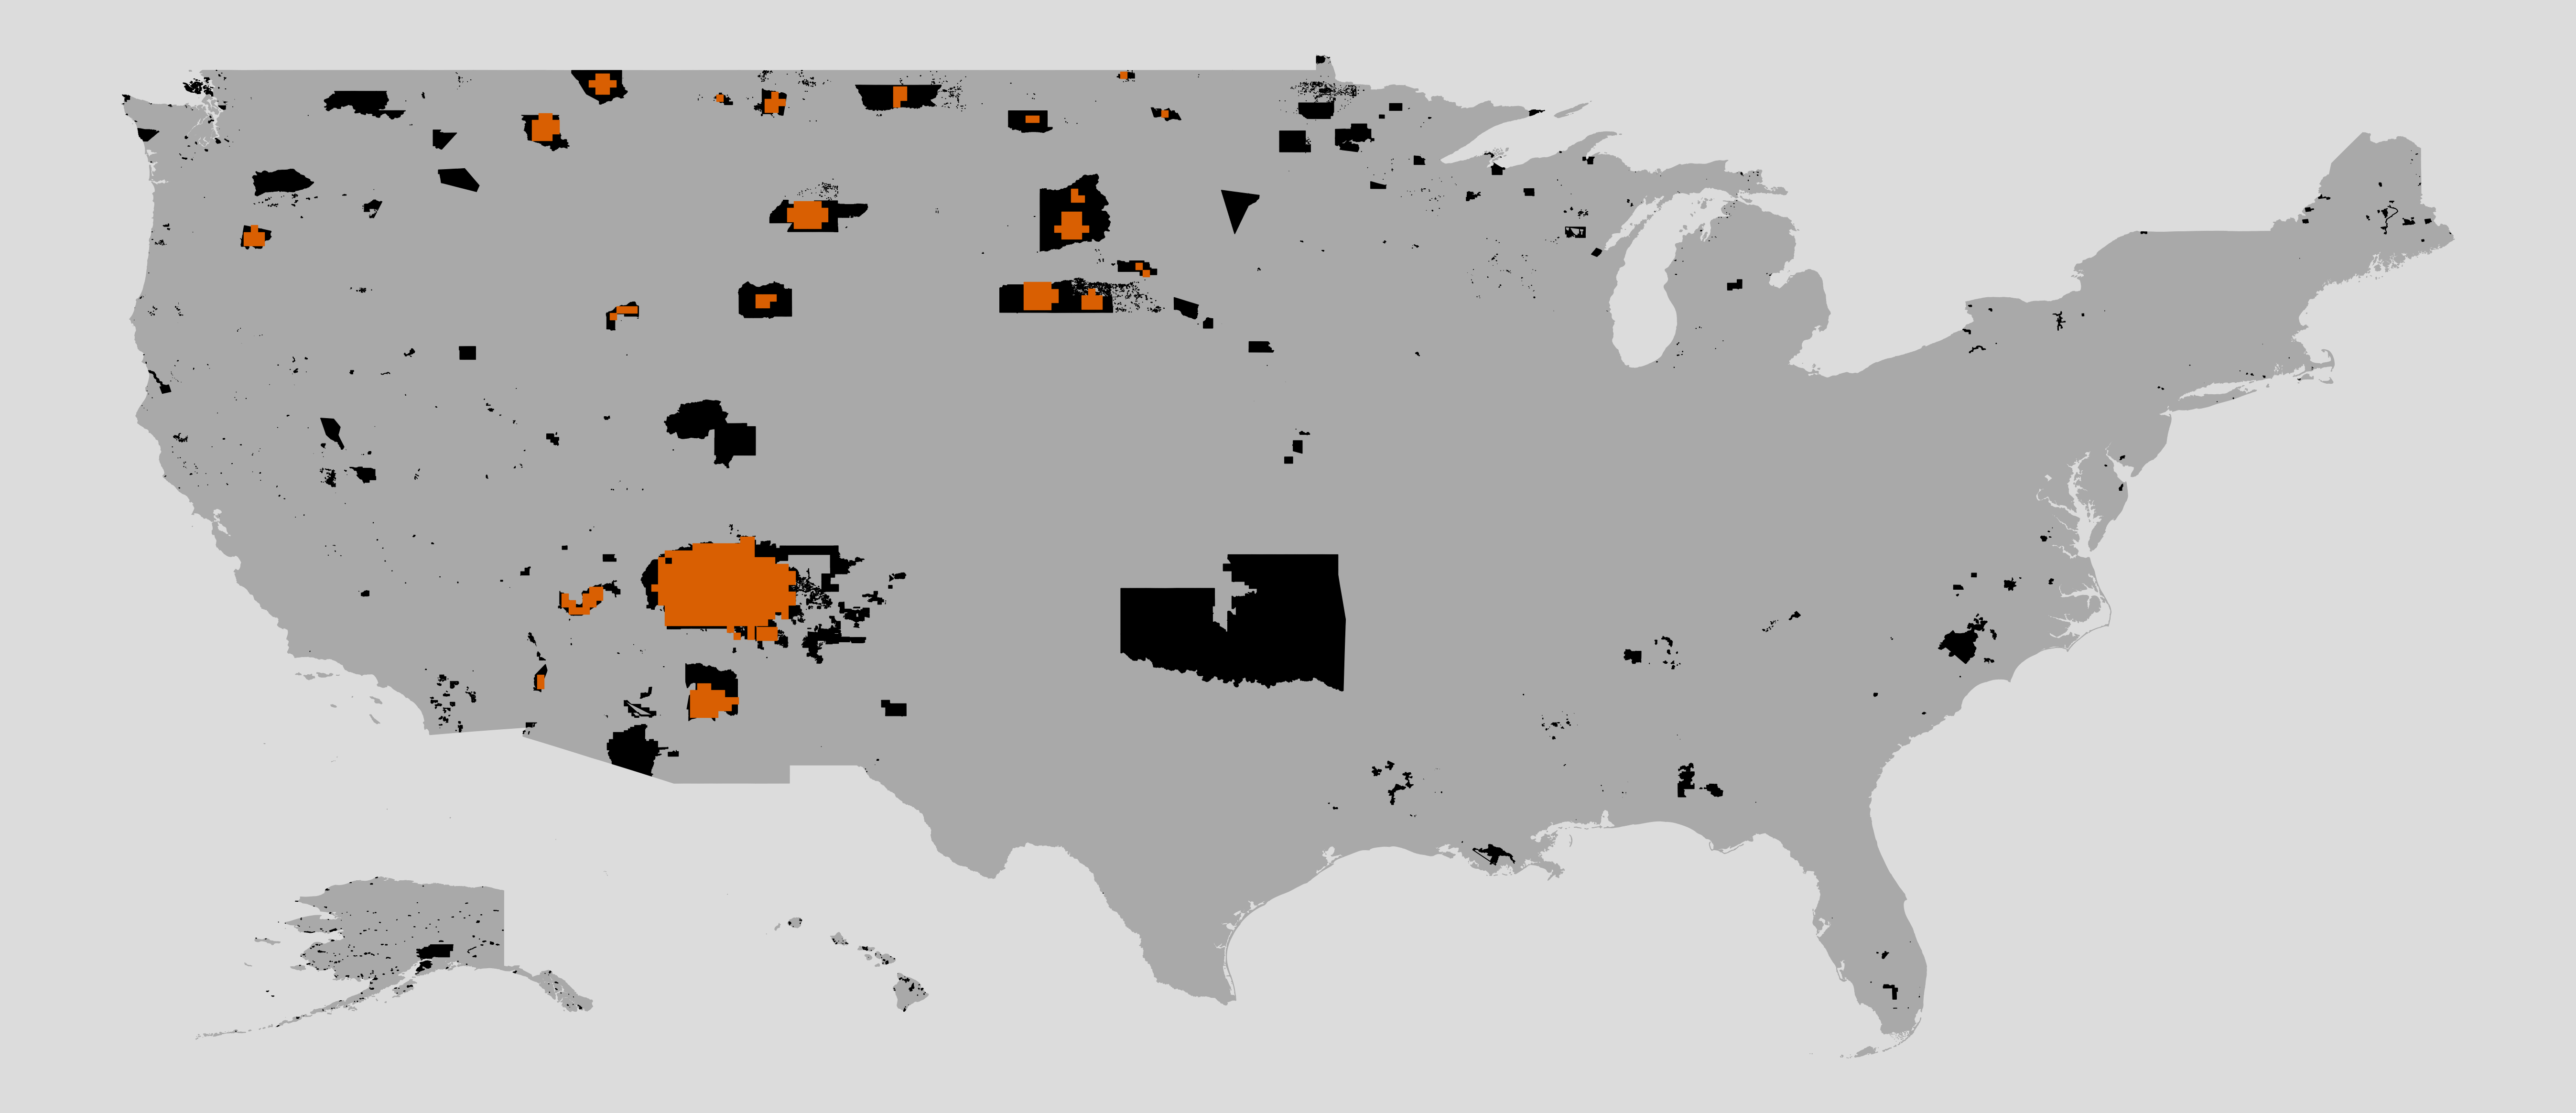

In [80]:
plt.figure(figsize=(18*size_mag,8*size_mag), facecolor=face)

# plot grid by color
for i in range(len(new_df["nation"])):
    curr_nation = new_df["nation"].iloc[i]
    grid_index = nation_names.index(curr_nation)
    if len(grid_ordered[grid_index])==0:
        continue
    curr_cols = nation_cols[i] # get current nation colors
    curr_grid_x = grid_ordered[grid_index][0] # get current grid x points
    curr_grid_y = grid_ordered[grid_index][1] # get current grid y points
    for j in range(len(curr_cols)):
        plt.scatter(curr_grid_x[j], curr_grid_y[j], c=curr_cols[j], marker=marker_type, s=pt_size, zorder=2)
        plt.gca().set_aspect("equal")


# plot single nations
for i in range(len(nation_names_s)):
    plt.fill(nation_coords_s[i][0], nation_coords_s[i][1], c="k", zorder=1)
    plt.gca().set_aspect("equal")
    plt.axis("off")

# plot multi nations
for i in range(len(nation_names_m)):
    for j in range(len(nation_coords_m[i])):
        plt.fill(nation_coords_m[i][j][0], nation_coords_m[i][j][1], c="k", zorder=1)
        plt.gca().set_aspect("equal")
        plt.axis("off")

# plot single alaska
for i in range(len(new_ak_coords_s)):
    plt.fill(new_ak_coords_s[i][0], new_ak_coords_s[i][1], c="k", zorder=1)
    plt.gca().set_aspect("equal")
    plt.axis("off")

# plot multi alaska
for i in range(len(new_ak_coords_m)):
    multi_coords = new_ak_coords_m[i]
    for j in range(len(multi_coords)):
        plt.fill(multi_coords[j][0], multi_coords[j][1], c="k", zorder=1)
        plt.gca().set_aspect("equal")
        plt.axis("off")

# plot single hawaii
for i in range(len(new_hi_coords_s)):
    plt.fill(new_hi_coords_s[i][0], new_hi_coords_s[i][1], c="k", zorder=1)
    plt.gca().set_aspect("equal")
    plt.axis("off")

# plot multi hawaii
for i in range(len(new_hi_coords_m)):
    multi_coords = new_hi_coords_m[i]
    for j in range(len(multi_coords)):
        plt.fill(multi_coords[j][0], multi_coords[j][1], c="k", zorder=1)
        plt.gca().set_aspect("equal")
        plt.axis("off")

# plot original single states
for i in range(len(state_coords_s)):
    curr_coords = state_coords_s[i]
    #plt.plot(curr_coords[0], curr_coords[1], c=c_state_plot, lw=lw_states, alpha=a_state_plot, zorder=0)
    plt.fill(curr_coords[0], curr_coords[1], c=c_state_fill, alpha=a_state_fill, zorder=0)
    plt.gca().set_aspect("equal")

# plot original multipolygon states
for i in range(len(state_coords_m)):
    curr_coords = state_coords_m[i]
    for j in range(len(curr_coords)):
        #plt.plot(curr_coords[j][0], curr_coords[j][1], c=c_state_plot, lw=lw_states, alpha=a_state_plot, zorder=0)
        plt.fill(curr_coords[j][0], curr_coords[j][1], c=c_state_fill, alpha=a_state_fill, zorder=0)
        plt.gca().set_aspect("equal")

plt.axis("off")
plt.tight_layout()
plt.savefig("./OUTPUTS/FIGURE1/nations_map.png")

# FIGURE 3: Clustering states in US and Mexico by demographic and agricultural information
-----------
----------

# State clustering

In [81]:
# read in data
df_acres = pd.read_csv("./USDA_maps/acres_farms_principal_producer_2017.csv")

# remove US data for now
df_acres = df_acres.iloc[1:,:]

# get the total value for each state
df_acres["total"] = df_acres["white"]+df_acres["Latino"]+df_acres["Indigenous"]+df_acres["Asian"]+df_acres["Black"]+df_acres["PacificIslander"]+df_acres["Mixed"]

# make new acres dataframe for merging
df_acres2 = pd.DataFrame({"state":df_acres["state"],
                          "white_acres":df_acres["white"]/df_acres["total"],
                          "Latino_acres":df_acres["Latino"]/df_acres["total"],
                          "Indigenous_acres":df_acres["Indigenous"]/df_acres["total"],
                          "Asian_acres":df_acres["Asian"]/df_acres["total"],
                          "Black_acres":df_acres["Black"]/df_acres["total"],
                          "PacificIslander_acres":df_acres["PacificIslander"]/df_acres["total"],
                          "Mixed_acres":df_acres["Mixed"]/df_acres["total"],
                         })

In [82]:
# read in data
df_pop = pd.read_csv("./USDA_maps/population_map_race_2020.csv")

# remove US data for now
df_pop = df_pop.iloc[1:,:]

# get the total value for each state
df_pop["total"] = df_pop["white"]+df_pop["Latino"]+df_pop["Indigenous"]+df_pop["Asian"]+df_pop["Black"]+df_pop["PacificIslander"]+df_pop["Mixed"]+df_pop["Other"]

# combine pop mixed + other to compare with acres
df_pop["Mixed2"] = df_pop["Other"] + df_pop["Mixed"]

# make new pop dataframe for merging
df_pop2 = pd.DataFrame({"state":df_pop["state"],
                          "white_pop":df_pop["white"]/df_pop["total"],
                          "Latino_pop":df_pop["Latino"]/df_pop["total"],
                          "Indigenous_pop":df_pop["Indigenous"]/df_pop["total"],
                          "Asian_pop":df_pop["Asian"]/df_pop["total"],
                          "Black_pop":df_pop["Black"]/df_pop["total"],
                          "PacificIslander_pop":df_pop["PacificIslander"]/df_pop["total"],
                          "Mixed_pop":df_pop["Mixed2"]/df_pop["total"],
                         })

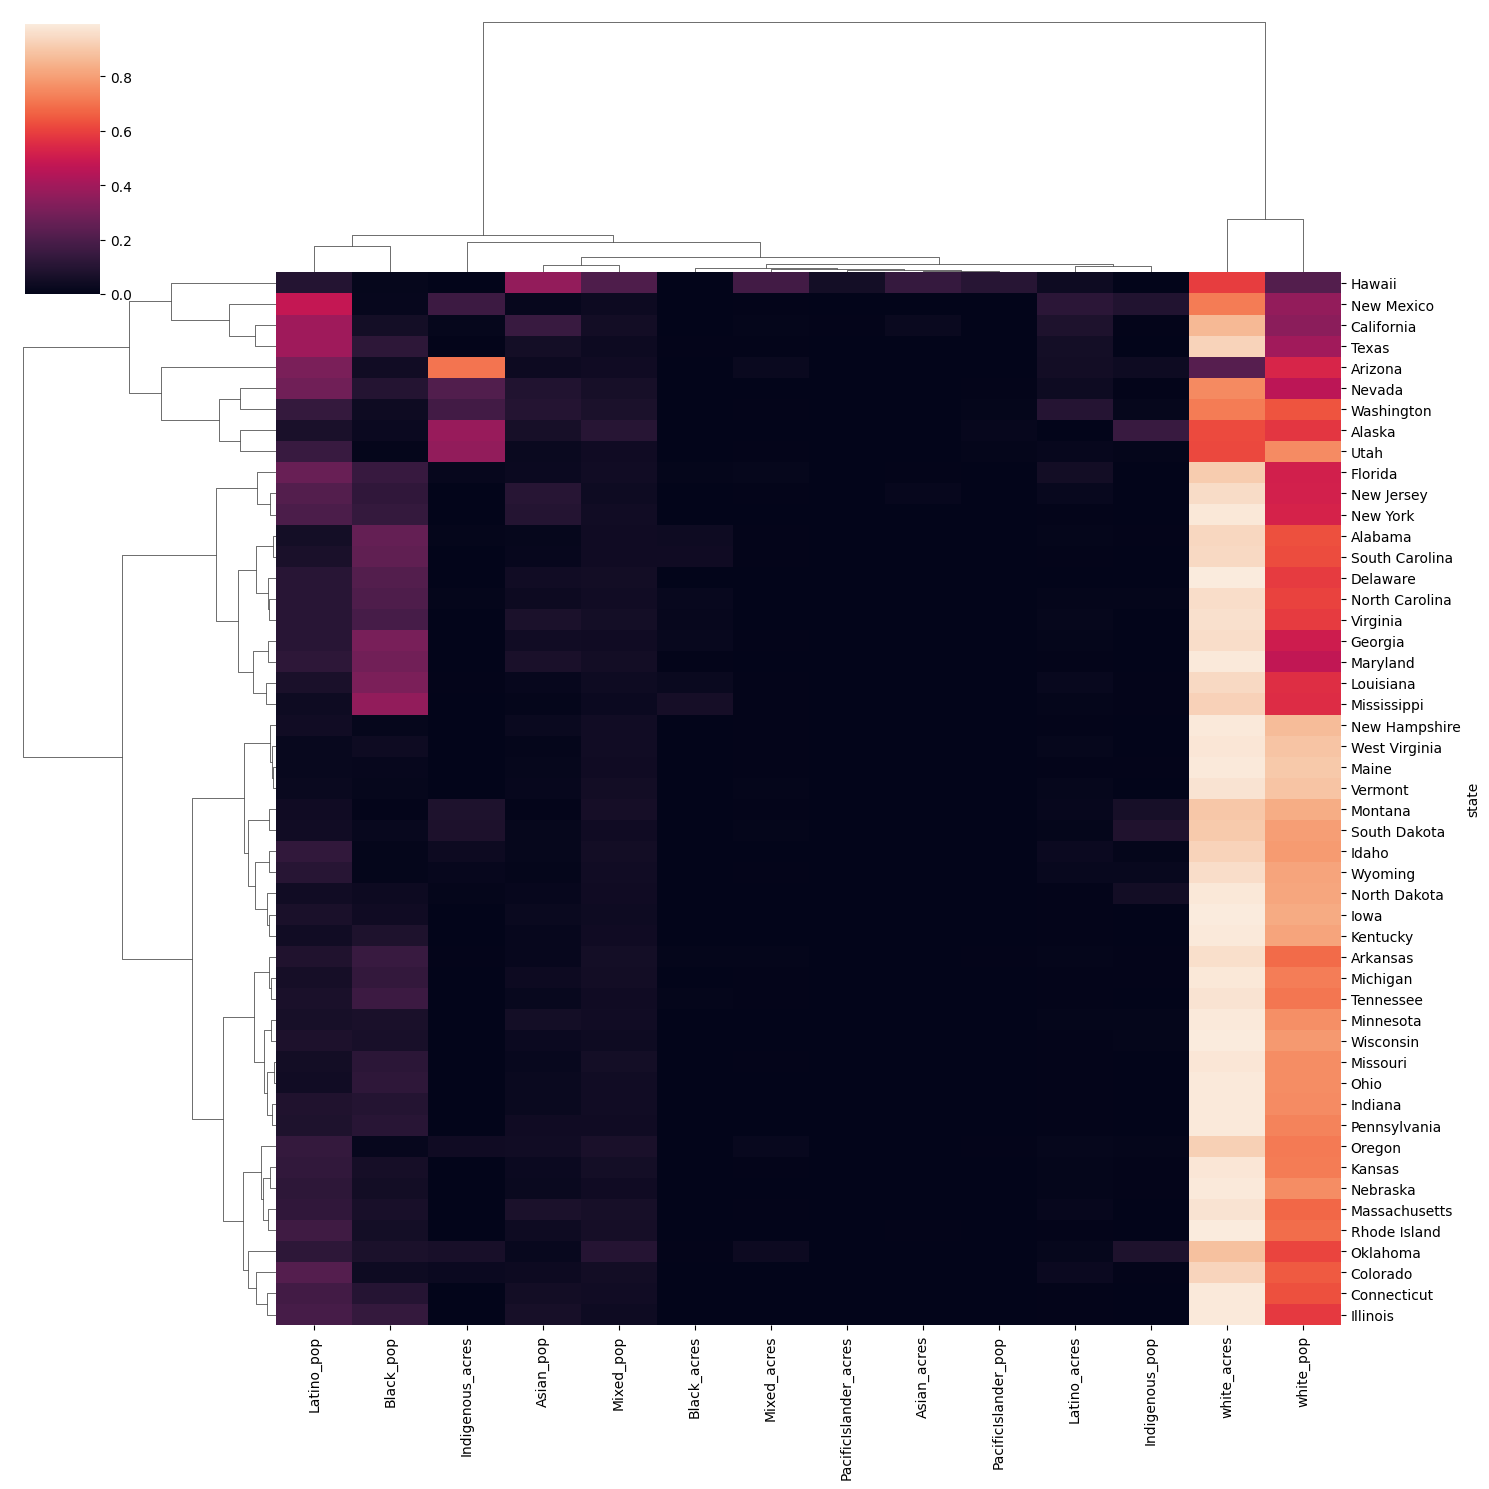

In [83]:
df_states = pd.merge(df_acres2, df_pop2, on="state")
df_states = df_states.set_index('state')

# methods: average, single, complete, weighted, centroid, median, ward

# ward, complete, weighted
sns.clustermap(df_states, method="ward", figsize=(15,15))

plt.savefig("./OUTPUTS/FIGURE3/US_clustermap.png")

In [84]:
# groups based on above heatmap
group1 = ["Hawaii","New Mexico","California","Texas"]
group2 = ["Arizona","Nevada","Washington","Alaska","Utah"]
group3 = ["Florida","New Jersey","New York","Alabama","South Carolina","Delaware","North Carolina","Virginia",
          "Georgia","Maryland","Louisiana","Mississippi"]
group4 = ["New Hampshire","West Virginia","Maine","Vermont","Montana","South Dakota","Idaho","Wyoming",
          "North Dakota","Iowa","Kentucky","Arkansas","Michigan","Tennessee","Minnesota","Wisconsin",
          "Missouri","Ohio","Indiana","Pennsylvania","Oregon","Kansas","Nebraska","Massahusetts",
          "Rhode Island","Oklahoma","Colorado","Connecticut","Illinois"]

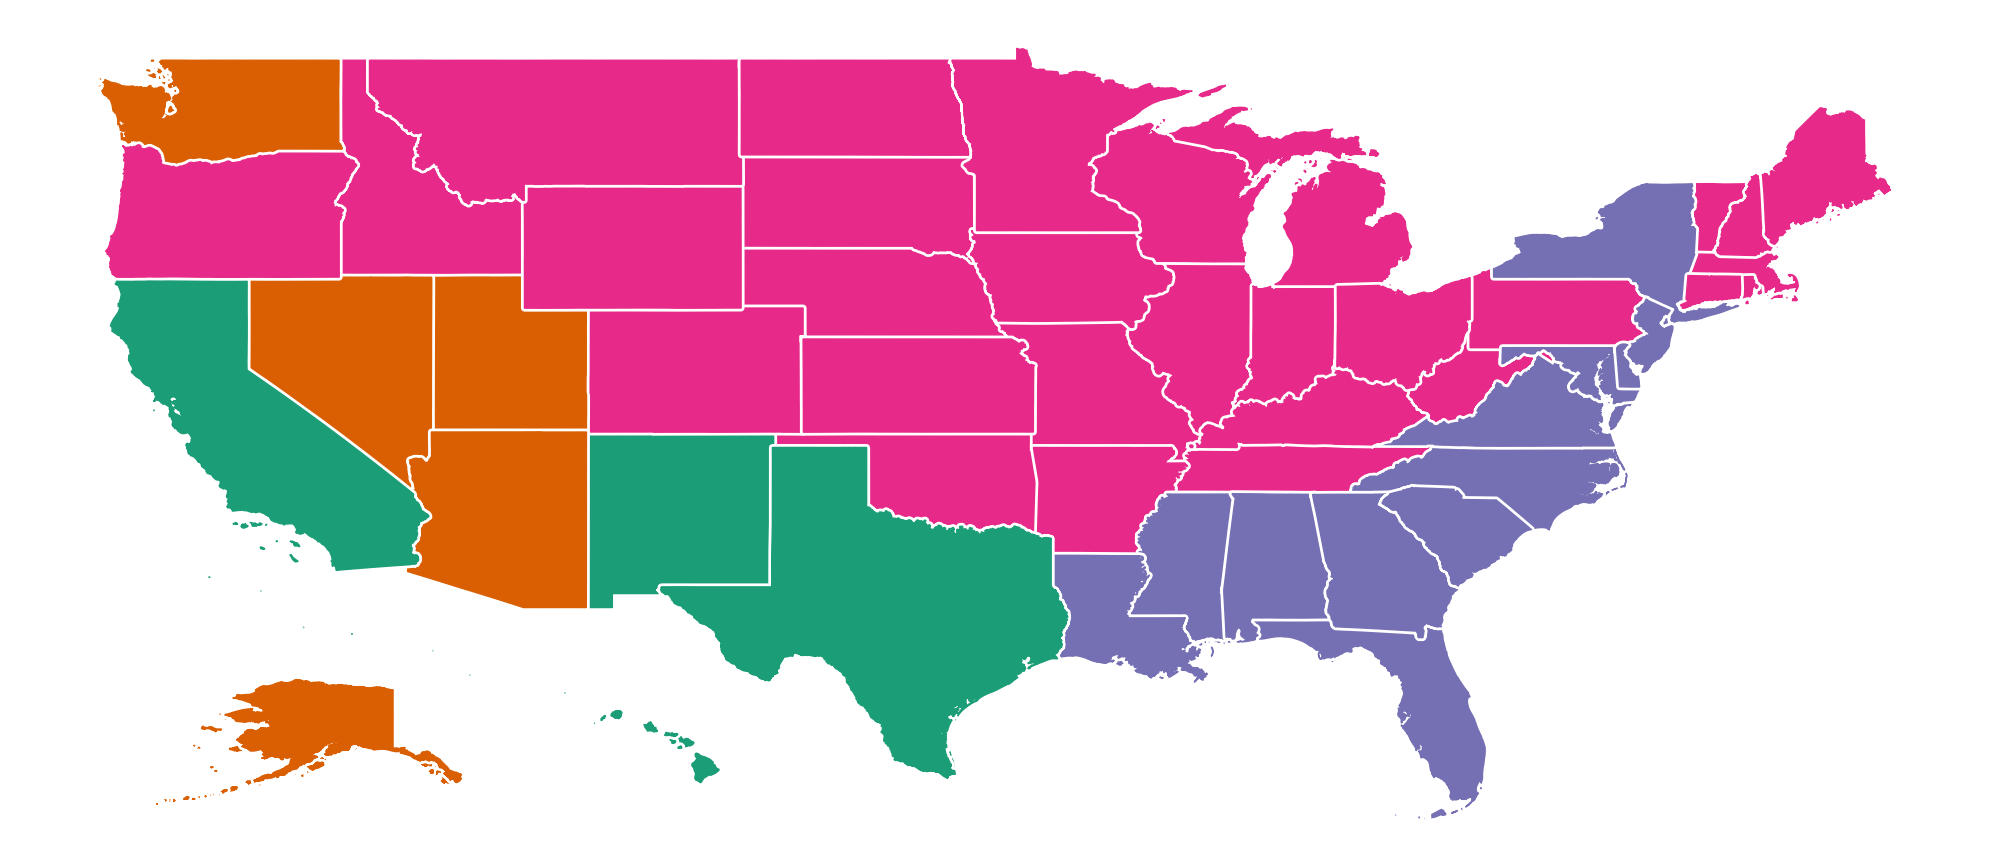

In [85]:
pt_size = 90 # point size
marker_type = "s"
lw_states = 5
c_state_fill = "darkgray"
c_state_plot = "white"
face= "white"
a_state_fill = 1
a_state_plot = 1
size_mag=3

plt.figure(figsize=(20,18))

# plot original single states
for i in range(len(state_coords_s)):
    curr_coords = state_coords_s[i]
    curr_name = state_names_s[i]

    if curr_name in group1:
        c_state_fill = '#1b9e77'
    elif curr_name in group2:
        c_state_fill = '#d95f02'
    elif curr_name in group3:
        c_state_fill = '#7570b3'
    elif curr_name in group4:
        c_state_fill = '#e7298a'
    
    plt.plot(curr_coords[0], curr_coords[1], c=c_state_plot, lw=lw_states, alpha=a_state_plot, zorder=0)
    plt.fill(curr_coords[0], curr_coords[1], c=c_state_fill, alpha=a_state_fill, zorder=0)
    plt.gca().set_aspect("equal")

# plot original multipolygon states
for i in range(len(state_coords_m)):
    curr_coords = state_coords_m[i]
    curr_name = state_names_m[i]

    if curr_name in group1:
        c_state_fill = '#1b9e77'
    elif curr_name in group2:
        c_state_fill = '#d95f02'
    elif curr_name in group3:
        c_state_fill = '#7570b3'
    elif curr_name in group4:
        c_state_fill = '#e7298a'

    for j in range(len(curr_coords)):
        plt.plot(curr_coords[j][0], curr_coords[j][1], c=c_state_plot, lw=lw_states, alpha=a_state_plot, zorder=0)
        plt.fill(curr_coords[j][0], curr_coords[j][1], c=c_state_fill, alpha=a_state_fill, zorder=0)
        plt.gca().set_aspect("equal")



plt.axis("off")

plt.tight_layout()
plt.savefig("./OUTPUTS/FIGURE3/US_regions_map.png")

